<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/TP1_Series_Temporales_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 1 — Análisis de Series Temporales

## Dinámica temporal de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York, 2025-2026

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen


---



### Configuración del entorno, conexión a Google Drive y carga de bases de datos

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
    print("Entorno local detectado: se omite el montaje de Google Drive.")

Mounted at /content/drive


In [ ]:
!pip install great_tables --break-system-packages
!pip install pmdarima --break-system-packages
!pip install optuna
!pip install arch -q
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 23.0 MB/s eta 0:00:00


In [ ]:

import pathlib

COLAB_DIR = pathlib.Path('/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1')
DATA_FOLDER = 'data'

if EN_COLAB:
    DATA_DIR = COLAB_DIR / DATA_FOLDER
else:
    DATA_DIR = LOCAL_DIR / DATA_FOLDER

ARCHIVOS = {
    'taxi_verde_williamsburg': DATA_DIR / 'green_taxi_williamsburg_trips.csv',
    'uber_williamsburg': DATA_DIR / 'uber_williamsburg_trips.csv',
    'uber_midtown': DATA_DIR / 'uber_midtown_center_trips.csv',
}

for nombre, ruta in ARCHIVOS.items():
    estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
    print(f"  {nombre}: {ruta.name} [{estado}]")

  taxi_verde_williamsburg: green_taxi_williamsburg_trips.csv [NO ENCONTRADO]
  uber_williamsburg: uber_williamsburg_trips.csv [NO ENCONTRADO]
  uber_midtown: uber_midtown_center_trips.csv [NO ENCONTRADO]


In [ ]:
print(f"Contenido de {DATA_DIR}:")
for item in DATA_DIR.iterdir():
    print(item.name)

Contenido de /content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1/data:
ingresos_diarios.csv
optuna


In [ ]:
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Directorio '{DATA_DIR}' creado.")
else:
    print(f"Directorio '{DATA_DIR}' ya existe.")

print(f"Contenido actualizado de {DATA_DIR}:")
if DATA_DIR.exists():
    for item in DATA_DIR.iterdir():
        print(item.name)
else:
    print(f"El directorio '{DATA_DIR}' aún no existe o no es accesible.")

Directorio '/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1/data' ya existe.
Contenido actualizado de /content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Práctico 1/data:
ingresos_diarios.csv
optuna


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
DATA_PATH = DATA_DIR / 'ingresos_diarios.csv'
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.asfreq('D')

In [ ]:
df.head()

,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2025-06-01,"1,330.87","211,438.32","143,511.61"
2025-06-02,34.00,"99,843.77","280,218.67"
2025-06-03,12.45,"98,417.60","408,118.11"
2025-06-04,10.50,"125,811.14","490,394.09"
2025-06-05,76.10,"148,409.88","547,902.82"


### 2. Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie


#### Gráfico 1. Evolución temporal y medias móviles a 7 días de los ingresos totales de Uber en Williamsburg y en Midtown Center, y de Taxi Verde en Williamsburg, 06/2025-05/2026

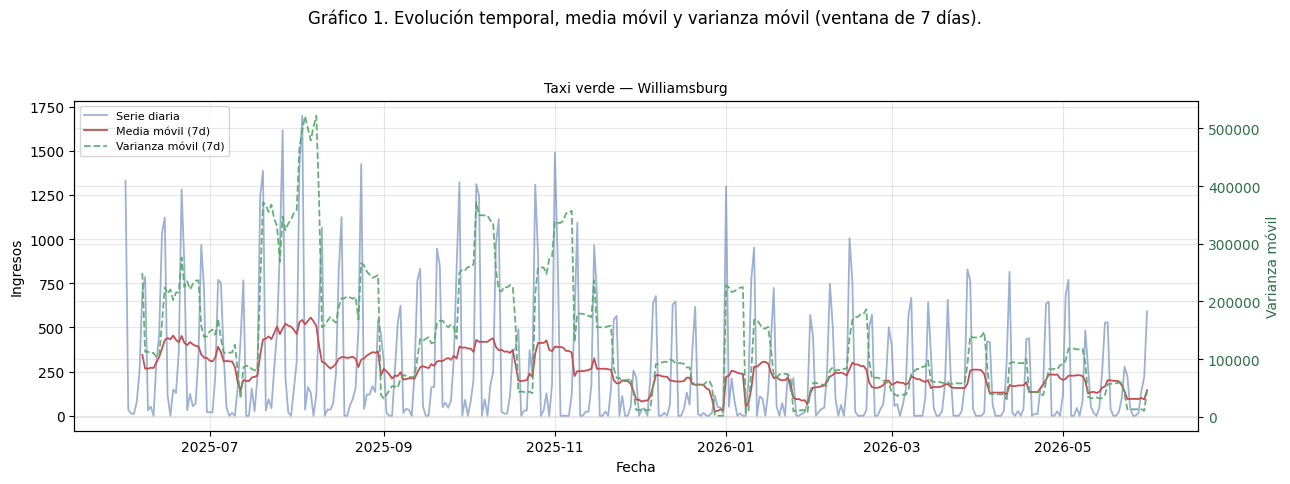

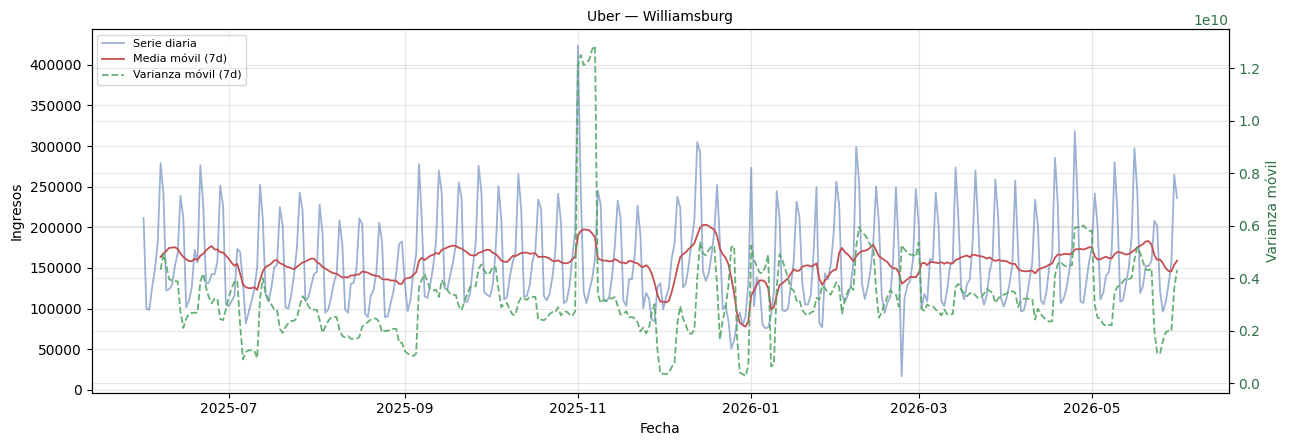

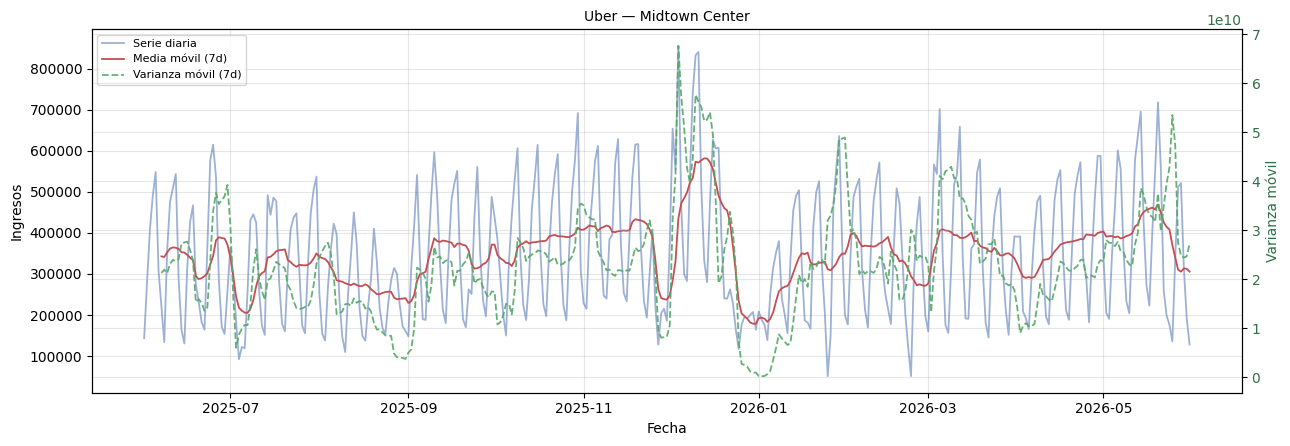

In [ ]:
columnas = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}

VENTANA = 7

for idx, (col, titulo) in enumerate(columnas.items()):
    serie = df[col]
    media_movil = serie.rolling(VENTANA).mean()
    var_movil = serie.rolling(VENTANA).var()

    fig, ax1 = plt.subplots(figsize=(13, 4.8))
    if idx == 0:
        fig.suptitle('Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días).',
                     fontsize=12, y=1.0)

    ax1.plot(serie.index, serie.values, lw=1.3, alpha=0.55, color='#4C72B0', label='Serie diaria')
    ax1.plot(serie.index, media_movil, lw=1.3, color='#C44E52', label=f'Media móvil ({VENTANA}d)')
    ax1.set_ylabel('Ingresos')
    ax1.set_xlabel('Fecha')

    ax2 = ax1.twinx()
    ax2.plot(serie.index, var_movil, lw=1.3, color='#55A868', alpha=0.9,
              linestyle='--', label=f'Varianza móvil ({VENTANA}d)')
    ax2.set_ylabel('Varianza móvil', color='#2E7047')
    ax2.tick_params(axis='y', labelcolor='#2E7047')

    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', fontsize=8)

    ax1.set_title(titulo, fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### Gráfico 2. Ingreso promedio por día de la semana para cada serie temporal

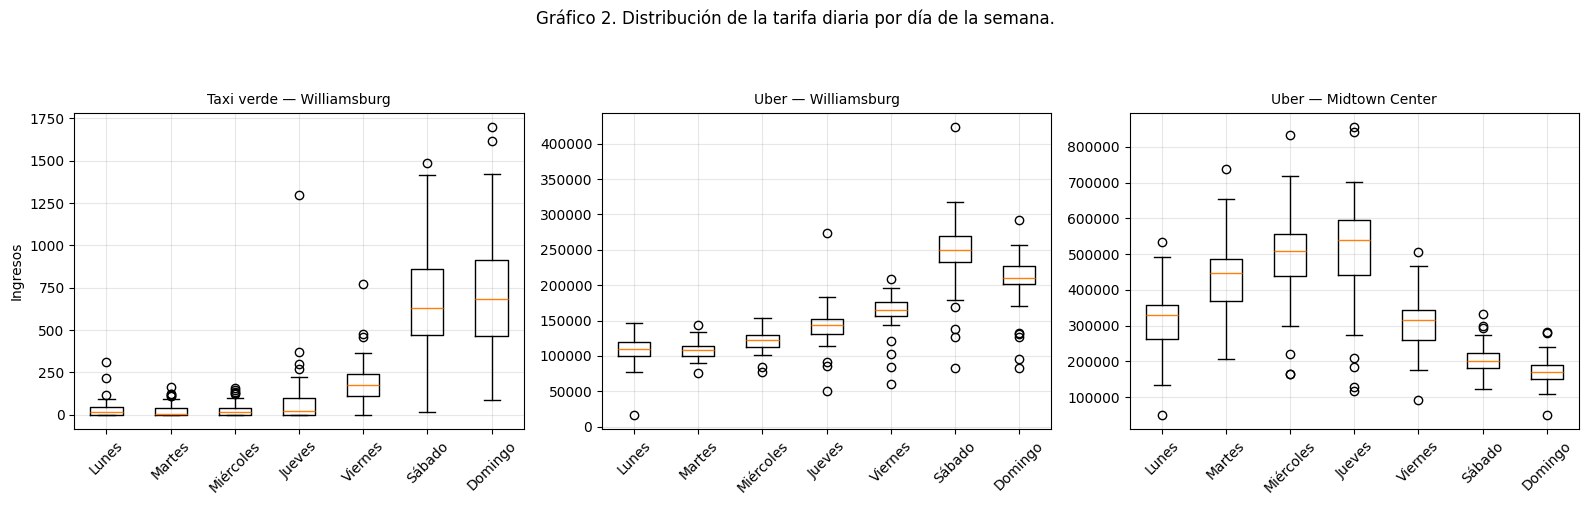

In [ ]:
dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Gráfico 2. Distribución de la tarifa diaria por día de la semana.',
             fontsize=12,  y=1)

for i, (col, titulo) in enumerate(columnas.items()):
    serie = df[col]
    tmp = pd.DataFrame({
        'valor': serie.values,
        'dia_semana': serie.index.dayofweek,
    })
    tmp['dia_semana'] = tmp['dia_semana'].map(dict(enumerate(dias_orden)))

    ax = axes[i]
    data_dia = [tmp.loc[tmp['dia_semana'] == d, 'valor'] for d in dias_orden]
    ax.boxplot(data_dia, tick_labels=dias_orden)
    ax.set_title(titulo, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.set_ylabel('Ingresos')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

WINDOW_SIZE = 7  # fijo — no lo cambies entre corridas si querés comparar resultados


def analyze_rango_mediana(series, window_size=WINDOW_SIZE):
    """
    Divide la serie en subgrupos, calcula rango y mediana,
    y ajusta: ln(Rango) = a + b * ln(Mediana)
    Descarta subgrupos con mediana o rango <= 0 (no admiten logaritmo).
    """
    n = len(series)
    num_groups = n // window_size
    medianas, rangos = [], []

    for i in range(num_groups):
        subgroup = series[i * window_size : (i + 1) * window_size]
        medianas.append(np.median(subgroup))
        rangos.append(np.max(subgroup) - np.min(subgroup))

    medianas, rangos = np.array(medianas), np.array(rangos)

    # filtro: descartar subgrupos no aptos para log
    mask = (medianas > 0) & (rangos > 0)
    n_descartados = (~mask).sum()
    if n_descartados > 0:
        print(f'  [aviso] se descartaron {n_descartados} de {len(medianas)} subgrupos por mediana o rango <= 0')
    medianas, rangos = medianas[mask], rangos[mask]

    log_medianas, log_rangos = np.log(medianas), np.log(rangos)
    slope, intercept = np.polyfit(log_medianas, log_rangos, 1)

    y_pred = slope * log_medianas + intercept
    r_squared = 1 - (np.sum((log_rangos - y_pred) ** 2) / np.sum((log_rangos - np.mean(log_rangos)) ** 2))

    return {
        'medianas': medianas, 'rangos': rangos, 'intercept': intercept,
        'slope': slope, 'r_squared': r_squared, 'lambda_empirico': 1 - slope,
    }


def calcular_shift(series, margen=1.0):
    """Shift fijo y explícito para series con valores <= 0 (Box-Cox lo requiere)."""
    minimo = np.min(series)
    return (-minimo + margen) if minimo <= 0 else 0.0


def get_boxcox_ci(series, alpha=0.05):
    """
    Lambda óptimo por MLE y su IC al (1-alpha) usando scipy.stats.boxcox.
    Aplica shift automáticamente si la serie tiene valores <= 0.
    """
    shift = calcular_shift(series)
    series_shifted = np.array(series) + shift

    _, l_opt, ci = boxcox(series_shifted, alpha=alpha)
    ci_lower, ci_upper = ci

    return l_opt, ci_lower, ci_upper, shift

# --- Cálculo consolidado para las tres series ---

filas = []
detalle_grafico = {}

for col, titulo in columnas.items():
    serie_valores = df[col].dropna().values

    rm = analyze_rango_mediana(serie_valores, window_size=WINDOW_SIZE)
    l_opt, ci_inf, ci_sup, shift = get_boxcox_ci(serie_valores)

    filas.append({
        'Serie': titulo,
        'Pendiente (b)': rm['slope'],
        'R² (Ajuste empírico)': rm['r_squared'],
        'Lambda Empírico (1-b)': rm['lambda_empirico'],
        'Lambda Óptimo (MLE)': l_opt,
        'IC 95% Inferior': ci_inf,
        'IC 95% Superior': ci_sup,
    })

    detalle_grafico[col] = {**rm, 'titulo': titulo}

tabla_resultados = pd.DataFrame(filas)

from great_tables import GT, style, loc, md

tabla_gt = (
    GT(tabla_resultados)
    .tab_header(
        title=f'Tabla 1. Estabilización de varianza: Rango-Mediana (ventana={WINDOW_SIZE}) vs. Box-Cox MLE'
    )
    .fmt_number(
        columns=['Pendiente (b)', 'R² (Ajuste empírico)', 'Lambda Empírico (1-b)',
                 'Lambda Óptimo (MLE)', 'IC 95% Inferior', 'IC 95% Superior'],
        decimals=3
    )
    .cols_label(
        **{
            'Pendiente (b)': md('Pendiente<br>(b)'),
            'R² (Ajuste empírico)': md('R²<br>(ajuste empírico)'),
            'Lambda Empírico (1-b)': md('λ empírico<br>(1-b)'),
            'Lambda Óptimo (MLE)': md('λ óptimo<br>(MLE)'),
            'IC 95% Inferior': md('IC 95%<br>inferior'),
            'IC 95% Superior': md('IC 95%<br>superior'),
        }
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Serie')
    )
)

tabla_gt

  [aviso] se descartaron 2 de 52 subgrupos por mediana o rango <= 0


GT(_tbl_data=                       Serie  Pendiente (b)  R² (Ajuste empírico)  \
0  Taxi verde — Williamsburg           0.23                  0.24   
1        Uber — Williamsburg           0.30                  0.04   
2      Uber — Midtown Center           1.28                  0.51   

   Lambda Empírico (1-b)  Lambda Óptimo (MLE)  IC 95% Inferior  \
0                   0.77                 0.13             0.08   
1                   0.70                 0.17            -0.01   
2                  -0.28                 0.34             0.14   

   IC 95% Superior  
0             0.18  
1             0.37  
2             0.54  , _body=<great_tables._gt_data.Body object at 0x7b5e9bc7f230>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Pendiente (b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Pendiente<br>(b)'), column_align='right', column_width=None), ColInfo(var='R² (Ajuste empírico)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='R²<br>(ajuste empírico)'), column_align='right', column_width=None), ColInfo(var='Lambda Empírico (1-b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ empírico<br>(1-b)'), column_align='right', column_width=None), ColInfo(var='Lambda Óptimo (MLE)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ óptimo<br>(MLE)'), column_align='right', column_width=None), ColInfo(var='IC 95% Inferior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>inferior'), column_align='right', column_width=None), ColInfo(var='IC 95% Superior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>superior'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e9bc7ef90>, _spanners=Spanners([]), _heading=Heading(title='Tabla 1. Estabilización de varianza: Rango-Mediana (ventana=7) vs. Box-Cox MLE', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5e9bc7f620>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5e9bbe2ad0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b5e9bc7f770>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b5e9bc7f4d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInf

In [ ]:
# Transformación de raíz cuadrada sobre Uber — Midtown Center (λ teórico adoptado = 0.5)
assert (df['uber_midtown'].dropna() >= 0).all(), 'Hay valores negativos en uber_midtown, no se puede aplicar raíz cuadrada directo'

df_final = df.copy()
df_final['uber_midtown_sqrt'] = np.sqrt(df['uber_midtown'])

df_final[['uber_midtown', 'uber_midtown_sqrt']].head()

,uber_midtown,uber_midtown_sqrt
fecha,,
2025-06-01,"143,511.61",378.83
2025-06-02,"280,218.67",529.36
2025-06-03,"408,118.11",638.84
2025-06-04,"490,394.09",700.28
2025-06-05,"547,902.82",740.20


In [ ]:
import pandas as pd
from pmdarima.arima.seasonality import OCSBTest, CHTest
from great_tables import GT, style, loc, md

M = 7  # período estacional a testear (semanal, dado que los datos son diarios)

filas = []
for col, titulo in columnas.items():
    # usa la versión log si existe en el df, si no la original
    col_usar = f'{col}_log' if f'{col}_log' in df_final.columns else col
    valores = df_final[col_usar].dropna().values

    D_ocsb = OCSBTest(m=M).estimate_seasonal_differencing_term(valores)
    D_ch = CHTest(m=M).estimate_seasonal_differencing_term(valores)

    filas.append({
        'Serie': titulo,
        'D (OCSB)': D_ocsb,
        'D (Canova-Hansen)': D_ch,
    })

tabla_estacional_df = pd.DataFrame(filas)

tabla_estacional_gt = (
    GT(tabla_estacional_df)
    .tab_header(
        title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)',
        subtitle=f'Orden de diferenciación estacional recomendado (m={M})'
    )
    .cols_label(
        **{
            'D (OCSB)': md('D<br>(OCSB)'),
            'D (Canova-Hansen)': md('D<br>(Canova-Hansen)'),
        }
    )
)

tabla_estacional_gt

GT(_tbl_data=                       Serie  D (OCSB)  D (Canova-Hansen)
0  Taxi verde — Williamsburg         0                  1
1        Uber — Williamsburg         0                  0
2      Uber — Midtown Center         0                  0, _body=<great_tables._gt_data.Body object at 0x7b5e9844c640>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='D (OCSB)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(OCSB)'), column_align='right', column_width=None), ColInfo(var='D (Canova-Hansen)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(Canova-Hansen)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e98406490>, _spanners=Spanners([]), _heading=Heading(title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)', subtitle='Orden de diferenciación estacional recomendado (m=7)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5e98406d50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5e9844cd60>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b5e98406ad0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsI

### 3. Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de los gráficos?. Justificar con teoría.

In [ ]:
from statsmodels.tsa.stattools import acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Definición de títulos y cantidad de rezagos
titulos = {
    'taxi_verde_williamsburg':
        'Taxi verde — Williamsburg',

    'uber_williamsburg':
        'Uber — Williamsburg',

    'uber_midtown_sqrt':
        'Uber — Midtown Center (SQRT)'
}

MAX_LAGS = 35

In [ ]:
# Función para graficar FAS, FAC y FACP
def graficar_dependencia_temporal(
    datos,
    titulo_general,
    max_lags=35
):
    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(17, 12)
    )

    for fila, (columna, titulo) in enumerate(titulos.items()):

        serie = datos[columna].dropna()

        # FAS
        autocovarianzas = acovf(
            serie,
            adjusted=False,
            demean=True,
            fft=True,
            nlag=max_lags
        )

        axes[fila, 0].stem(
            range(len(autocovarianzas)),
            autocovarianzas,
            basefmt=' '
        )

        axes[fila, 0].axhline(
            0,
            color='black',
            linewidth=0.8
        )

        axes[fila, 0].set_title(
            f'FAS — {titulo}'
        )

        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            ax=axes[fila, 1]
        )

        axes[fila, 1].set_title(
            f'FAC — {titulo}'
        )

        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(
            serie,
            lags=max_lags,
            alpha=0.05,
            zero=True,
            method='ywm',
            ax=axes[fila, 2]
        )

        axes[fila, 2].set_title(
            f'FACP — {titulo}'
        )

        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(
        titulo_general,
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

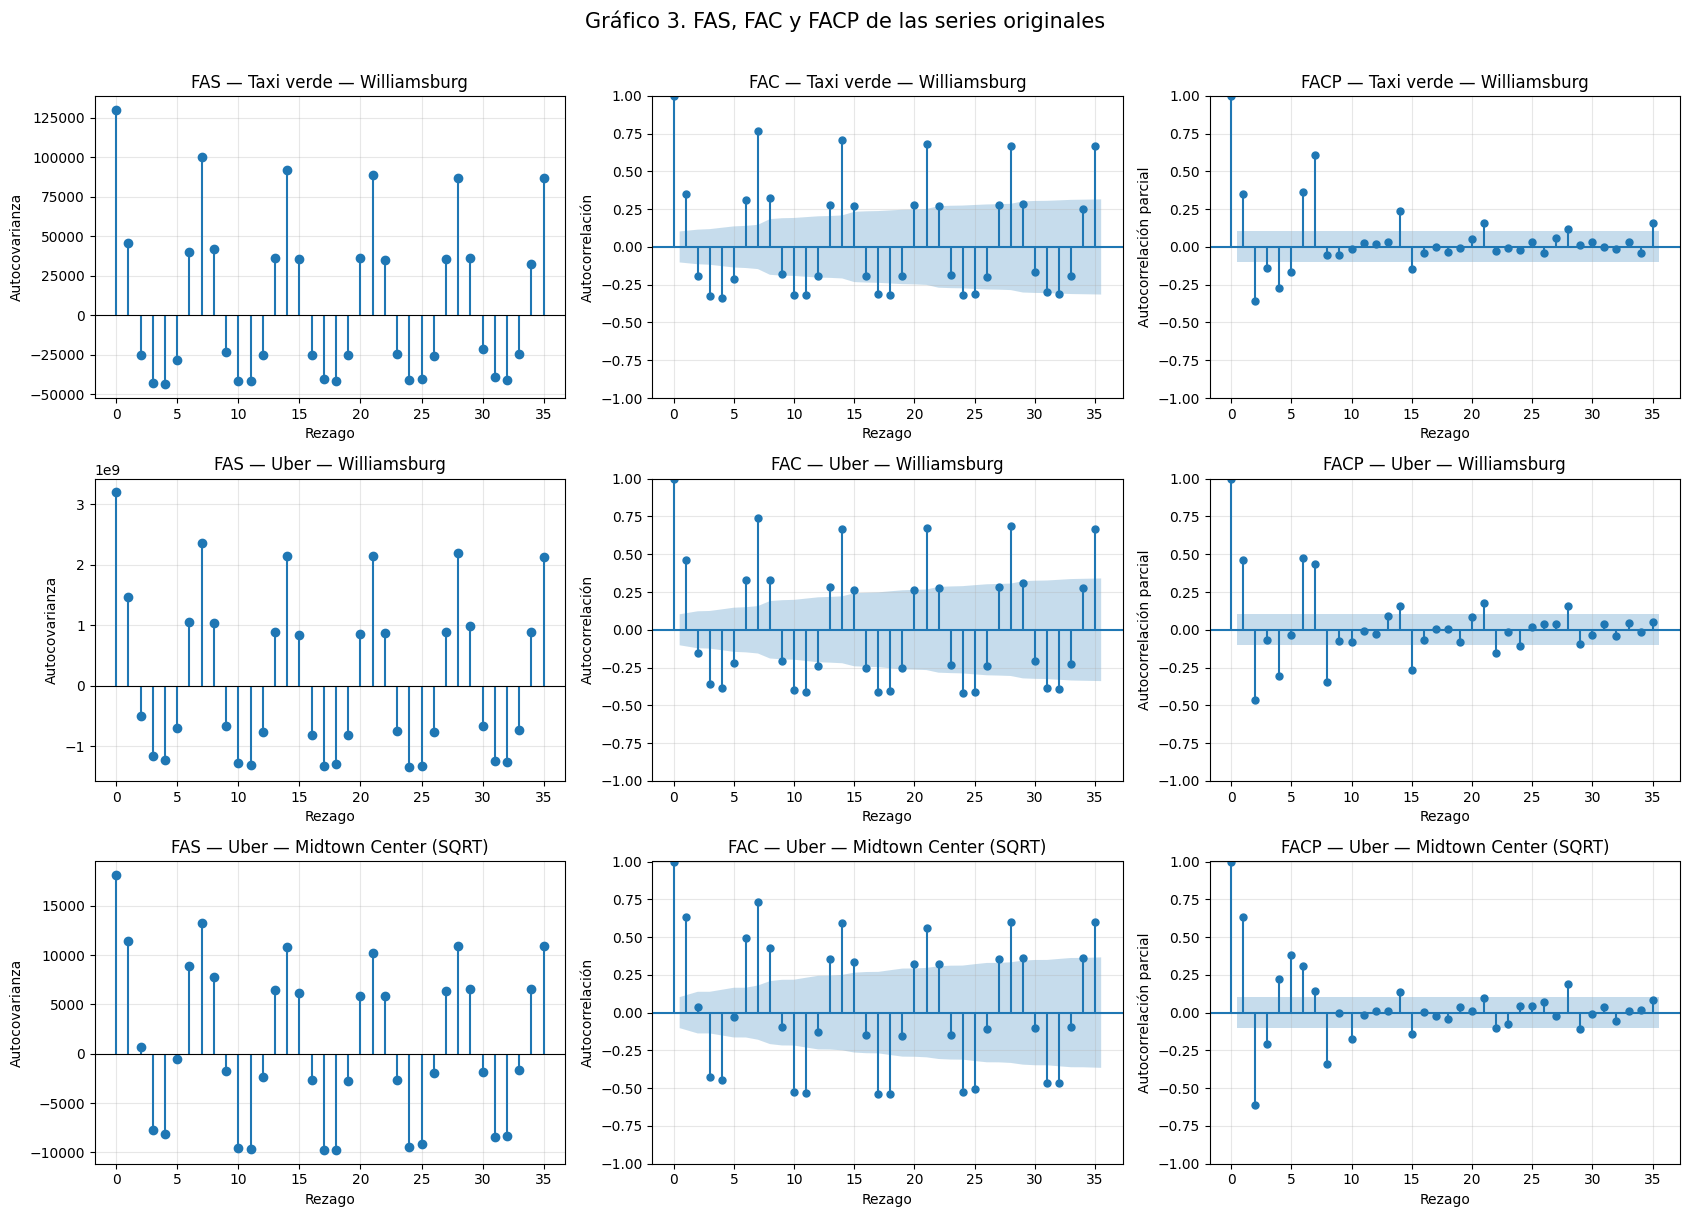

In [ ]:
# Graficar las series originales
graficar_dependencia_temporal(
    datos=df_final,
    titulo_general='Gráfico 3. FAS, FAC y FACP de las series originales',
    max_lags=MAX_LAGS
)

### 4. Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias.


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

def pruebas_raiz_unitaria(
    serie,
    nombre,
    especificacion='c'
):
    """
    Aplica las pruebas ADF, Phillips-Perron y KPSS.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """

    serie = serie.dropna()

    # Dickey-Fuller aumentado
    adf = adfuller(
        serie,
        regression=especificacion,
        autolag='AIC'
    )

    # Phillips-Perron
    pp = PhillipsPerron(
        serie,
        trend=especificacion
    )

    # KPSS
    kpss_resultado = kpss(
        serie,
        regression=especificacion,
        nlags='auto'
    )

    return pd.DataFrame({
        'Serie': [nombre] * 3,

        'Prueba': [
            'ADF',
            'Phillips-Perron',
            'KPSS'
        ],

        'Estadístico': [
            adf[0],
            pp.stat,
            kpss_resultado[0]
        ],

        'p-valor': [
            adf[1],
            pp.pvalue,
            kpss_resultado[1]
        ],

        'Rezagos': [
            adf[2],
            pp.lags,
            kpss_resultado[2]
        ]
    })

In [ ]:
# Aplicación a series diferenciadas estacionalmente
resultados_diferenciada = []

for columna, titulo in titulos.items():
    # usar la versión transformada (sqrt para Midtown) si existe, si no la original
    col_usar = f'{columna}_sqrt' if f'{columna}_sqrt' in df_final.columns else columna

    resultado = pruebas_raiz_unitaria(
        serie=df_final[col_usar],
        nombre=f'{titulo}',
        especificacion='c'
    )

    resultados_diferenciada.append(resultado)

tabla_diferenciada = pd.concat(
    resultados_diferenciada,
    ignore_index=True
)

tabla_gt_dif = (
    GT(tabla_diferenciada)
    .tab_header(
        title="Tabla 3. Pruebas de Raíz Unitaria (ADF vs. Phillips-Perron vs. KPSS)",
    )
    .fmt_number(
        columns=["Estadístico", "p-valor"],
        decimals=4
    )
    .tab_options(
        table_font_names="Arial",
    )
)

tabla_gt_dif

/tmp/ipykernel_4055/2388279840.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_4055/2388279840.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


GT(_tbl_data=                          Serie           Prueba  Estadístico  p-valor  \
0     Taxi verde — Williamsburg              ADF        -2.76     0.06   
1     Taxi verde — Williamsburg  Phillips-Perron       -12.79     0.00   
2     Taxi verde — Williamsburg             KPSS         1.24     0.01   
3           Uber — Williamsburg              ADF        -5.11     0.00   
4           Uber — Williamsburg  Phillips-Perron       -10.35     0.00   
5           Uber — Williamsburg             KPSS         0.11     0.10   
6  Uber — Midtown Center (SQRT)              ADF        -4.19     0.00   
7  Uber — Midtown Center (SQRT)  Phillips-Perron        -8.05     0.00   
8  Uber — Midtown Center (SQRT)             KPSS         0.38     0.09   

   Rezagos  
0       14  
1       17  
2       17  
3       15  
4       17  
5       13  
6       14  
7       17  
8        6  , _body=<great_tables._gt_data.Body object at 0x7b5e984396a0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Prueba', type=<ColInfoTypeEnum.default: 1>, column_label='Prueba', column_align='left', column_width=None), ColInfo(var='Estadístico', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e9156d6d0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 3. Pruebas de Raíz Unitaria (ADF vs. Phillips-Perron vs. KPSS)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5e9844d940>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5e9815c5f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b5e9156da90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b5e9156de50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px')

In [ ]:
# Diferenciación estacional de orden 7 sobre Taxi Verde — Williamsburg
df_final['taxi_verde_williamsburg_dif7'] = df_final['taxi_verde_williamsburg'].diff(7)

df_final[['taxi_verde_williamsburg', 'taxi_verde_williamsburg_dif7']].head(10)

titulos = {
    'taxi_verde_williamsburg_dif7':
        'Taxi verde — Williamsburg (Diferenciación 7)',

    'uber_williamsburg':
        'Uber — Williamsburg',

    'uber_midtown_sqrt':
        'Uber — Midtown Center (SQRT)'
}

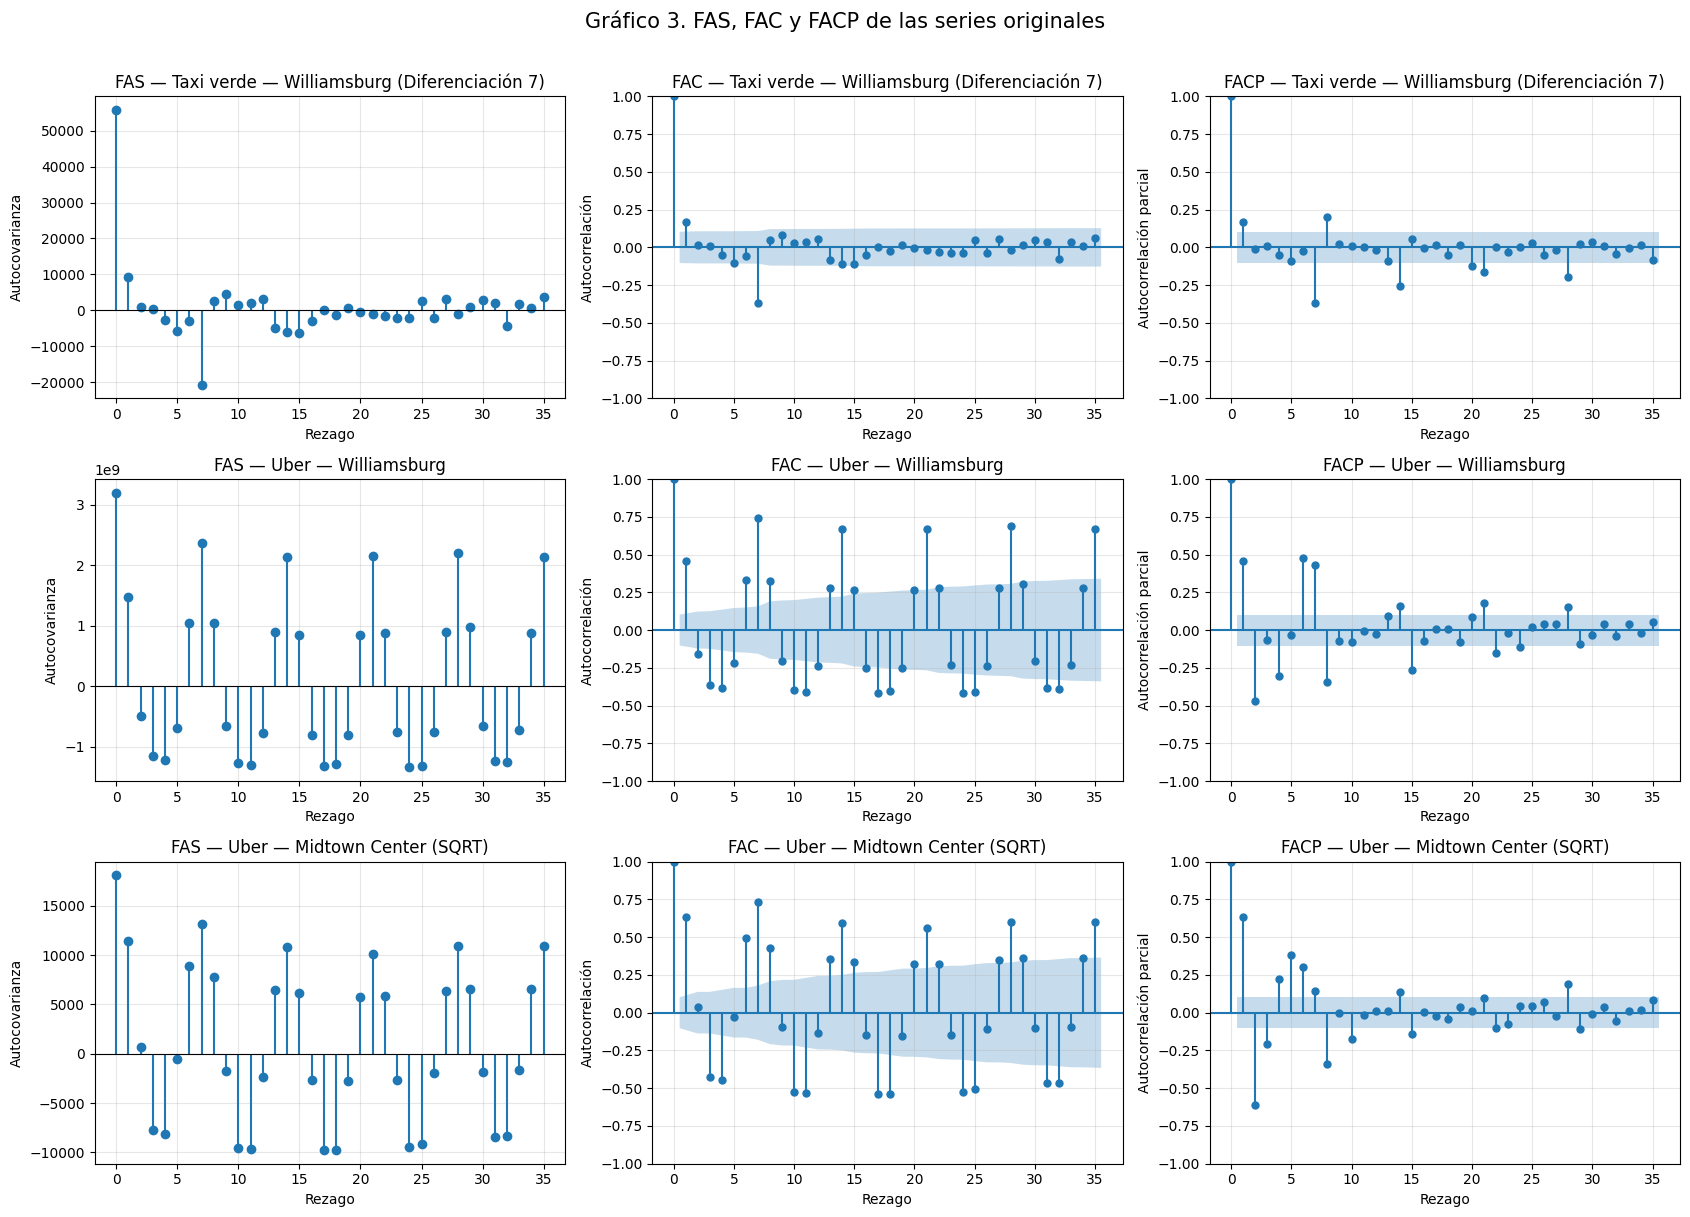

In [ ]:
# Graficar las series originales
graficar_dependencia_temporal(
    datos=df_final,
    titulo_general='Gráfico 3. FAS, FAC y FACP de las series originales',
    max_lags=MAX_LAGS
)

In [ ]:
# Aplicación a series diferenciadas estacionalmente
resultados_diferenciada = []

for columna, titulo in titulos.items():
    # usar la versión transformada (sqrt para Midtown) si existe, si no la original
    col_usar = f'{columna}_sqrt' if f'{columna}_sqrt' in df_final.columns else columna

    resultado = pruebas_raiz_unitaria(
        serie=df_final[col_usar],
        nombre=f'{titulo}',
        especificacion='c'
    )

    resultados_diferenciada.append(resultado)

tabla_diferenciada = pd.concat(
    resultados_diferenciada,
    ignore_index=True
)

tabla_gt_dif = (
    GT(tabla_diferenciada)
    .tab_header(
        title="Tabla 3. Pruebas de Raíz Unitaria (ADF vs. Phillips-Perron vs. KPSS)",
    )
    .fmt_number(
        columns=["Estadístico", "p-valor"],
        decimals=4
    )
    .tab_options(
        table_font_names="Arial",
    )
)

tabla_gt_dif

/tmp/ipykernel_4055/2388279840.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(
/tmp/ipykernel_4055/2388279840.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado = kpss(


GT(_tbl_data=                                          Serie           Prueba  Estadístico  \
0  Taxi verde — Williamsburg (Diferenciación 7)              ADF        -7.66   
1  Taxi verde — Williamsburg (Diferenciación 7)  Phillips-Perron       -15.90   
2  Taxi verde — Williamsburg (Diferenciación 7)             KPSS         0.01   
3                           Uber — Williamsburg              ADF        -5.11   
4                           Uber — Williamsburg  Phillips-Perron       -10.35   
5                           Uber — Williamsburg             KPSS         0.11   
6                  Uber — Midtown Center (SQRT)              ADF        -4.19   
7                  Uber — Midtown Center (SQRT)  Phillips-Perron        -8.05   
8                  Uber — Midtown Center (SQRT)             KPSS         0.38   

   p-valor  Rezagos  
0     0.00       13  
1     0.00       17  
2     0.10        3  
3     0.00       15  
4     0.00       17  
5     0.10       13  
6     0.00       14  
7     0.00       17  
8     0.09        6  , _body=<great_tables._gt_data.Body object at 0x7b5e91578850>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Prueba', type=<ColInfoTypeEnum.default: 1>, column_label='Prueba', column_align='left', column_width=None), ColInfo(var='Estadístico', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e9844da70>, _spanners=Spanners([]), _heading=Heading(title='Tabla 3. Pruebas de Raíz Unitaria (ADF vs. Phillips-Perron vs. KPSS)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5e98439ae0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5e98439d00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b5e9844dba0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b5e91a70a50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style

### 5. Efectuar una estimación de la serie temporal con distintos órdenes de parámetros de modelos SARIMA y encontrar aquel que se ajuste mejor a los datos (pueden emplear Criterios de Información/Selección y analizar significatividad individual y global de los parámetros del modelo).

### 6. Evaluar alguna métrica de performance teniendo en cuenta el entrenamiento del modelo entre Training Set y Testing Set.

In [ ]:
import itertools
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from great_tables import GT, style, loc, md
import optuna
from optuna.samplers import TPESampler
import pathlib
import pickle

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [ ]:
def dividir_train_test(serie):
    """
    Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test

In [ ]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX


def sarima_gridsearch(train, s=7, criterio='AIC',
                       p=(0, 3), d=(0, 0), q=(0, 2),
                       P=(0, 1), D=(0, 0), Q=(0, 2),
                       exog=None, verbose=True):
    """
    Búsqueda exhaustiva de hiperparámetros SARIMA/SARIMAX por grid search.
    Ajusta un modelo para cada combinación posible de (p,d,q)(P,D,Q,s)
    dentro de los rangos dados, y evalúa por AIC/BIC.
    Test no participa en ningún momento de esta etapa.

    criterio: 'AIC' o 'BIC', solo se usa para el orden final de la tabla.
    p, d, q, P, D, Q: tuplas (min, max) inclusive para cada orden.

    Devuelve df_res: tabla con todas las combinaciones válidas, ordenada
    por criterio (mismo formato que sarima_optuna).
    """
    rangos_p = range(p[0], p[1] + 1)
    rangos_d = range(d[0], d[1] + 1)
    rangos_q = range(q[0], q[1] + 1)
    rangos_P = range(P[0], P[1] + 1)
    rangos_D = range(D[0], D[1] + 1)
    rangos_Q = range(Q[0], Q[1] + 1)

    combinaciones = list(itertools.product(
        rangos_p, rangos_d, rangos_q, rangos_P, rangos_D, rangos_Q
    ))

    if verbose:
        print(f'  Grid search: {len(combinaciones)} combinaciones a evaluar.')

    resultados = []
    for i, (pp, dd, qq, PP, DD, QQ) in enumerate(combinaciones):
        order = (pp, dd, qq)
        seasonal_order = (PP, DD, QQ, s)

        try:
            modelo = SARIMAX(
                train, exog=exog, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            )
            fit = modelo.fit(disp=False)
        except Exception:
            continue

        resultados.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fit.aic,
            'BIC': fit.bic,
            'LLF': fit.llf,
        })

        if verbose and (i + 1) % 10 == 0:
            print(f'    {i + 1}/{len(combinaciones)} combinaciones evaluadas...')

    df_res = pd.DataFrame(resultados).sort_values(by=criterio).reset_index(drop=True)
    df_res = df_res.drop_duplicates(subset=['order', 'seasonal_order']).reset_index(drop=True)

    if verbose:
        print(f'  Completado: {len(df_res)} modelos válidos de {len(combinaciones)} combinaciones.')

    return df_res

In [ ]:
import pandas as pd
from great_tables import GT, style, loc, md

configuracion_series = {
    'taxi_verde_williamsburg': {
        'columna_serie': 'taxi_verde_williamsburg',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 1),
        'P': (0, 1), 'D': (1, 1), 'Q': (0, 2),
    },
    'uber_williamsburg': {
        'columna_serie': 'uber_williamsburg',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 2),
        'P': (1, 2), 'D': (0, 0), 'Q': (0, 2),
    },
    'uber_midtown': {
        'columna_serie': 'uber_midtown_sqrt',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 2),
        'P': (1, 2), 'D': (0, 0), 'Q': (0, 2),
    },
}

parametros = ['p', 'd', 'q', 'P', 'D', 'Q']

filas = []
for parametro in parametros:
    fila = {'Parámetro': parametro}
    for col, config in configuracion_series.items():
        titulo_col = columnas[col]  # usa el diccionario 'columnas' con los nombres lindos
        rango = config[parametro]
        fila[titulo_col] = f'({rango[0]}, {rango[1]})'
    filas.append(fila)

tabla_espacio_df = pd.DataFrame(filas)

tabla_espacio_gt = (
    GT(tabla_espacio_df)
    .tab_header(
        title='Tabla 5. Espacio de búsqueda de hiperparámetros SARIMA',
        subtitle='Rangos (mín, máx) por parámetro y serie, usados en la búsqueda con GridSearch'
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Parámetro')
    )
    .tab_options(
        table_font_names='Arial',
    )
)

tabla_espacio_gt

GT(_tbl_data=  Parámetro Taxi verde — Williamsburg Uber — Williamsburg  \
0         p                    (0, 3)              (0, 3)   
1         d                    (0, 0)              (0, 0)   
2         q                    (0, 1)              (0, 2)   
3         P                    (0, 1)              (1, 2)   
4         D                    (1, 1)              (0, 0)   
5         Q                    (0, 2)              (0, 2)   

  Uber — Midtown Center  
0                (0, 3)  
1                (0, 0)  
2                (0, 2)  
3                (1, 2)  
4                (0, 0)  
5                (0, 2)  , _body=<great_tables._gt_data.Body object at 0x7b5e9bb44050>, _boxhead=Boxhead([ColInfo(var='Parámetro', type=<ColInfoTypeEnum.default: 1>, column_label='Parámetro', column_align='left', column_width=None), ColInfo(var='Taxi verde — Williamsburg', type=<ColInfoTypeEnum.default: 1>, column_label='Taxi verde — Williamsburg', column_align='right', column_width=None), ColInfo(var='Uber — Williamsburg', type=<ColInfoTypeEnum.default: 1>, column_label='Uber — Williamsburg', column_align='right', column_width=None), ColInfo(var='Uber — Midtown Center', type=<ColInfoTypeEnum.default: 1>, column_label='Uber — Midtown Center', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e91845220>, _spanners=Spanners([]), _heading=Heading(title='Tabla 5. Espacio de búsqueda de hiperparámetros SARIMA', subtitle='Rangos (mín, máx) por parámetro y serie, usados en la búsqueda con GridSearch', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5e986cb150>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5e986cb350>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Parámetro', rows=None, mask=None), grpname=None, colname='Parámetro', rownum=5, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b5e91845480>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsI

In [ ]:
RESULTADOS_DIR = DATA_DIR / 'gridsearch'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

dict_resultados_gridsearch = {}

for col, config in configuracion_series.items():
    columna_serie = config['columna_serie']
    print(f'\nProcesando: {col} (usando columna "{columna_serie}")...')

    serie = df_final[columna_serie]
    train, test = dividir_train_test(serie)

    tabla_modelos = sarima_gridsearch(
        train, s=7, criterio='AIC',
        p=config['p'], d=config['d'], q=config['q'],
        P=config['P'], D=config['D'], Q=config['Q'],
    )

    dict_resultados_gridsearch[col] = {
        'columna_serie': columna_serie,
        'train': train,
        'test': test,
        'tabla_modelos': tabla_modelos,
    }

    archivo_pkl = RESULTADOS_DIR / f'gridsearch_sarima_{col}.pkl'
    with open(archivo_pkl, 'wb') as f:
        pickle.dump({
            'columna_serie': columna_serie,
            'train': train,
            'test': test,
            'tabla_modelos': tabla_modelos,
        }, f)
    print(f'  Guardado: {archivo_pkl.name}')


Procesando: taxi_verde_williamsburg (usando columna "taxi_verde_williamsburg")...
  Grid search: 48 combinaciones a evaluar.
    10/48 combinaciones evaluadas...
    20/48 combinaciones evaluadas...
    30/48 combinaciones evaluadas...
    40/48 combinaciones evaluadas...
  Completado: 48 modelos válidos de 48 combinaciones.
  Guardado: gridsearch_sarima_taxi_verde_williamsburg.pkl

Procesando: uber_williamsburg (usando columna "uber_williamsburg")...
  Grid search: 72 combinaciones a evaluar.
    10/72 combinaciones evaluadas...
    20/72 combinaciones evaluadas...
    30/72 combinaciones evaluadas...
    40/72 combinaciones evaluadas...
    50/72 combinaciones evaluadas...
    60/72 combinaciones evaluadas...
    70/72 combinaciones evaluadas...
  Completado: 72 modelos válidos de 72 combinaciones.
  Guardado: gridsearch_sarima_uber_williamsburg.pkl

Procesando: uber_midtown (usando columna "uber_midtown_sqrt")...
  Grid search: 72 combinaciones a evaluar.
    10/72 combinaciones ev

In [ ]:
import pandas as pd
from great_tables import GT, style, loc, md

filas_top5 = []

for col, resultado in dict_resultados_gridsearch.items():
    titulo_col = columnas[col]
    top5 = resultado['tabla_modelos'].head(3).copy()
    top5.insert(0, 'Serie', titulo_col)
    top5.insert(1, 'Ranking', range(1, len(top5) + 1))
    filas_top5.append(top5)

tabla_top5_df = pd.concat(filas_top5, ignore_index=True)

# order y seasonal_order son tuplas -> las paso a texto para que se vean bien en GT
tabla_top5_df['order'] = tabla_top5_df['order'].astype(str)
tabla_top5_df['seasonal_order'] = tabla_top5_df['seasonal_order'].astype(str)

tabla_top5_gt = (
    GT(tabla_top5_df)
    .tab_header(
        title='Tabla 6. Top 3 modelos SARIMA por serie',
        subtitle='Ordenados por AIC dentro de cada serie'
    )
    .fmt_number(columns=['AIC', 'BIC', 'LLF'], decimals=2)
    .cols_label(
        order=md('Orden<br>(p,d,q)'),
        seasonal_order=md('Orden estacional<br>(P,D,Q,s)'),
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Serie')
    )
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda df: df['Ranking'] == 1)
    )
)

tabla_top5_gt

GT(_tbl_data=                       Serie  Ranking      order seasonal_order      AIC  \
0  Taxi verde — Williamsburg        1  (0, 0, 1)   (0, 1, 2, 7) 4,173.87   
1  Taxi verde — Williamsburg        2  (0, 0, 1)   (1, 1, 2, 7) 4,174.75   
2  Taxi verde — Williamsburg        3  (1, 0, 1)   (0, 1, 2, 7) 4,175.81   
3        Uber — Williamsburg        1  (3, 0, 2)   (2, 0, 2, 7) 7,529.63   
4        Uber — Williamsburg        2  (3, 0, 2)   (2, 0, 1, 7) 7,530.41   
5        Uber — Williamsburg        3  (3, 0, 2)   (1, 0, 2, 7) 7,531.48   
6      Uber — Midtown Center        1  (1, 0, 2)   (1, 0, 2, 7) 3,487.23   
7      Uber — Midtown Center        2  (3, 0, 0)   (2, 0, 1, 7) 3,489.65   
8      Uber — Midtown Center        3  (1, 0, 1)   (1, 0, 2, 7) 3,495.29   

       BIC       LLF  
0 4,188.83 -2,082.94  
1 4,193.45 -2,082.37  
2 4,194.51 -2,082.90  
3 7,567.22 -3,754.82  
4 7,564.24 -3,756.20  
5 7,565.31 -3,756.74  
6 3,513.54 -1,736.61  
7 3,515.96 -1,737.82  
8 3,517.86 -1,741.64  , _body=<great_tables._gt_data.Body object at 0x7b5eabee8050>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Ranking', type=<ColInfoTypeEnum.default: 1>, column_label='Ranking', column_align='right', column_width=None), ColInfo(var='order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden<br>(p,d,q)'), column_align='right', column_width=None), ColInfo(var='seasonal_order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden estacional<br>(P,D,Q,s)'), column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None), ColInfo(var='LLF', type=<ColInfoTypeEnum.default: 1>, column_label='LLF', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b5e904b05f0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 6. Top 3 modelos SARIMA por serie', subtitle='Ordenados por AIC dentro de cada serie', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b5ea4d01220>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b5ea4d014f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=5, colnum=No

#7. Detallar una comparación con otros modelos estimados.

A continuación, se realiza una comparacion del modelo elegido SARIMA con modelos mas simples como ARIMA, AR y MA

In [ ]:
titulos = {
    'taxi_verde_williamsburg':
        'Taxi verde — Williamsburg',

    'uber_williamsburg':
        'Uber — Williamsburg',

    'uber_midtown_sqrt':
        'Uber — Midtown Center (SQRT)'
}

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

def evaluar_en_test(tabla_modelos, train, test, rank=1):
    """
    Toma el modelo en la posición `rank` (1-indexado) de `tabla_modelos`
    (ya ordenada por AIC). Si la fila trae 'fit_obj' (caso ARIMA/AR/MA,
    generados con seleccionar_modelo_generico) lo reutiliza; si no
    (caso SARIMA del grid search, que no guarda fit_obj), re-ajusta el
    modelo sobre `train` con el order/seasonal_order de esa fila.
    Genera el forecast sobre el horizonte de `test` y calcula RMSE y MAE.
    """
    fila = tabla_modelos.iloc[rank - 1]

    if 'fit_obj' in tabla_modelos.columns and fila['fit_obj'] is not None:
        fit_obj = fila['fit_obj']
    else:
        modelo = SARIMAX(
            train, order=fila['order'], seasonal_order=fila['seasonal_order'],
            enforce_stationarity=False, enforce_invertibility=False
        )
        fit_obj = modelo.fit(disp=False)

    forecast = fit_obj.get_forecast(steps=len(test))
    predicciones = forecast.predicted_mean
    predicciones.index = test.index

    rmse = np.sqrt(mean_squared_error(test, predicciones))
    mae = mean_absolute_error(test, predicciones)

    return {'rmse': rmse, 'mae': mae, 'predicciones': predicciones}

In [ ]:
def invertir_diff7(predicciones_dif, serie_nivel_completa):
    """
    Reconstruye el nivel a partir de un forecast hecho sobre la serie
    diferenciada en 7 (serie.diff(7)):
        nivel[t] = dif_pred[t] + nivel_real[t-7]
    `serie_nivel_completa` debe ser la serie ORIGINAL (sin diferenciar),
    con índice suficiente para cubrir t-7 de cada fecha en predicciones_dif
    (train + test).
    """
    lag_real = serie_nivel_completa.reindex(predicciones_dif.index - pd.Timedelta(days=7))
    lag_real.index = predicciones_dif.index  # realinear para poder sumar
    return predicciones_dif + lag_real

In [ ]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

BEST_SARIMA_RANKS = {
    'taxi_verde_williamsburg': 1,
    'uber_williamsburg': 2,
    'uber_midtown': 1,
}

series_names = ['uber_midtown', 'uber_williamsburg', 'taxi_verde_williamsburg']


def seleccionar_modelo_generico(train_series, p_range, d_range, q_range, P_range, D_range, Q_range, s_value, criterio='AIC'):
    """
    Grid search for SARIMA/ARIMA/AR/MA models.
    """
    pdq = list(itertools.product(p_range, d_range, q_range))
    seasonal_pdq = [(x[0], x[1], x[2], s_value) for x in itertools.product(P_range, D_range, Q_range)]

    resultados = []
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                model = SARIMAX(
                    train_series, order=param, seasonal_order=param_seasonal,
                    enforce_stationarity=False, enforce_invertibility=False,
                    initialization='approximate_diffuse'
                )
                fit = model.fit(disp=False)
                resultados.append({
                    'order': param,
                    'seasonal_order': param_seasonal,
                    'AIC': fit.aic,
                    'BIC': fit.bic,
                    'LLF': fit.llf,
                    'fit_obj': fit
                })
            except Exception:
                continue

    if not resultados:
        return pd.DataFrame(columns=['order', 'seasonal_order', 'AIC', 'BIC', 'LLF', 'fit_obj'])

    df_res = pd.DataFrame(resultados).sort_values(by=criterio).reset_index(drop=True)
    return df_res

In [ ]:
comparison_results_list = []

# D fijo alternativo por serie, para contrastar contra la definición original
D_ALT_FIJO = {
    'taxi_verde_williamsburg': 0,
    'uber_williamsburg': 1,
    'uber_midtown': 1,
}

for col in series_names:
    columna_serie = configuracion_series[col]['columna_serie']
    print(f"\n--- Serie: {columnas[col]} (columna: {columna_serie}) ---")

    current_series = df_final[columna_serie]
    train, test = dividir_train_test(current_series)

    # --- 1. SARIMA Model (del grid search ya corrido) ---
    sarima_info = dict_resultados_gridsearch[col]
    sarima_rank_to_use = BEST_SARIMA_RANKS[col]
    resultado_sarima = evaluar_en_test(
        sarima_info['tabla_modelos'], sarima_info['train'], sarima_info['test'], rank=sarima_rank_to_use
    )

    best_sarima_row = sarima_info['tabla_modelos'].iloc[sarima_rank_to_use - 1]
    best_sarima_order_str = f"{best_sarima_row['order']}x{best_sarima_row['seasonal_order']}"

    comparison_results_list.append({
        'Serie': columnas[col],
        'Modelo': f'SARIMA {best_sarima_order_str}',
        'RMSE': resultado_sarima['rmse'],
        'MAE': resultado_sarima['mae']
    })
    print(f"SARIMA (rank {sarima_rank_to_use}): RMSE={resultado_sarima['rmse']:.2f}, MAE={resultado_sarima['mae']:.2f}")

    # --- 1b. SARIMA con D fijo alternativo (mismo espacio de búsqueda, D distinto) ---
    D_fijo = D_ALT_FIJO[col]
    print(f"\nBuscando SARIMA con D fijo en {D_fijo}...")
    config_base = configuracion_series[col]
    tabla_sarima_alt = sarima_gridsearch(
        train, s=7, criterio='AIC',
        p=config_base['p'], d=config_base['d'], q=config_base['q'],
        P=config_base['P'], D=(D_fijo, D_fijo), Q=config_base['Q'],
    )

    if not tabla_sarima_alt.empty:
        best_sarima_alt_row = tabla_sarima_alt.iloc[0]
        resultado_sarima_alt = evaluar_en_test(tabla_sarima_alt, train, test, rank=1)
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'SARIMA (D={D_fijo}) {best_sarima_alt_row["order"]}x{best_sarima_alt_row["seasonal_order"]}',
            'RMSE': resultado_sarima_alt['rmse'],
            'MAE': resultado_sarima_alt['mae']
        })
        print(f"SARIMA (D={D_fijo}): RMSE={resultado_sarima_alt['rmse']:.2f}, MAE={resultado_sarima_alt['mae']:.2f}")
    else:
        print(f"No se pudo ajustar ningún modelo SARIMA con D={D_fijo}.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'SARIMA (D={D_fijo}, no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    # --- 2. ARIMA Model (no estacional, misma serie que SARIMA) ---
    print("\nBuscando el mejor modelo ARIMA (no estacional)...")
    p_arima = [0, 1, 2, 3]
    d_arima = [0, 1]
    q_arima = [0, 1, 2, 3]
    tabla_arima = seleccionar_modelo_generico(train, p_arima, d_arima, q_arima, [0], [0], [0], 0, criterio='AIC')

    if not tabla_arima.empty:
        best_arima_row = tabla_arima.iloc[0]
        resultado_arima = evaluar_en_test(tabla_arima, train, test, rank=1)
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'ARIMA {best_arima_row["order"]}',
            'RMSE': resultado_arima['rmse'],
            'MAE': resultado_arima['mae']
        })
        print(f"ARIMA: RMSE={resultado_arima['rmse']:.2f}, MAE={resultado_arima['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo ARIMA válido.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'ARIMA (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    # --- 3. AR Model ---
    print("\nBuscando el mejor modelo AR (no estacional)...")
    p_ar = [1, 2, 3, 4]
    d_ar = [0]
    q_ar = [0]
    tabla_ar = seleccionar_modelo_generico(train, p_ar, d_ar, q_ar, [0], [0], [0], 0, criterio='AIC')

    if not tabla_ar.empty:
        best_ar_row = tabla_ar.iloc[0]
        resultado_ar = evaluar_en_test(tabla_ar, train, test, rank=1)
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'AR ({best_ar_row["order"][0]})',
            'RMSE': resultado_ar['rmse'],
            'MAE': resultado_ar['mae']
        })
        print(f"AR: RMSE={resultado_ar['rmse']:.2f}, MAE={resultado_ar['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo AR válido.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'AR (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    # --- 4. MA Model ---
    print("\nBuscando el mejor modelo MA (no estacional)...")
    p_ma = [0]
    d_ma = [0]
    q_ma = [1, 2, 3, 4]
    tabla_ma = seleccionar_modelo_generico(train, p_ma, d_ma, q_ma, [0], [0], [0], 0, criterio='AIC')

    if not tabla_ma.empty:
        best_ma_row = tabla_ma.iloc[0]
        resultado_ma = evaluar_en_test(tabla_ma, train, test, rank=1)
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'MA ({best_ma_row["order"][2]})',
            'RMSE': resultado_ma['rmse'],
            'MAE': resultado_ma['mae']
        })
        print(f"MA: RMSE={resultado_ma['rmse']:.2f}, MAE={resultado_ma['mae']:.2f}")
    else:
        print("No se pudo ajustar ningún modelo MA válido.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'MA (no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    # --- 2b/3b/4b. ARIMA, AR y MA sobre la serie diferenciada (diff 7) ---
    print("\nArmando train/test sobre la serie diferenciada (diff 7)...")
    serie_dif7 = current_series.diff(7)
    train_dif7, test_dif7 = dividir_train_test(serie_dif7)

    print("Buscando el mejor modelo ARIMA sobre la serie diferenciada (diff 7)...")
    tabla_arima_dif7 = seleccionar_modelo_generico(train_dif7, p_arima, d_arima, q_arima, [0], [0], [0], 0, criterio='AIC')
    if not tabla_arima_dif7.empty:
        best_arima_dif7_row = tabla_arima_dif7.iloc[0]
        fit_obj_dif7 = best_arima_dif7_row['fit_obj']

        pred_dif7 = fit_obj_dif7.get_forecast(steps=len(test_dif7)).predicted_mean
        pred_dif7.index = test_dif7.index
        pred_nivel = invertir_diff7(pred_dif7, current_series)

        rmse_dif7 = np.sqrt(mean_squared_error(current_series.reindex(test_dif7.index), pred_nivel))
        mae_dif7 = mean_absolute_error(current_series.reindex(test_dif7.index), pred_nivel)

        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'ARIMA (dif7) {best_arima_dif7_row["order"]}',
            'RMSE': rmse_dif7,
            'MAE': mae_dif7
        })
        print(f"ARIMA (dif7, nivel): RMSE={rmse_dif7:.2f}, MAE={mae_dif7:.2f}")
    else:
        print("No se pudo ajustar ningún modelo ARIMA válido sobre dif7.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'ARIMA (dif7, no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    print("\nBuscando el mejor modelo AR sobre la serie diferenciada (diff 7)...")
    tabla_ar_dif7 = seleccionar_modelo_generico(train_dif7, p_ar, d_ar, q_ar, [0], [0], [0], 0, criterio='AIC')
    if not tabla_ar_dif7.empty:
        best_ar_dif7_row = tabla_ar_dif7.iloc[0]
        fit_obj_dif7 = best_ar_dif7_row['fit_obj']

        pred_dif7 = fit_obj_dif7.get_forecast(steps=len(test_dif7)).predicted_mean
        pred_dif7.index = test_dif7.index
        pred_nivel = invertir_diff7(pred_dif7, current_series)

        rmse_dif7 = np.sqrt(mean_squared_error(current_series.reindex(test_dif7.index), pred_nivel))
        mae_dif7 = mean_absolute_error(current_series.reindex(test_dif7.index), pred_nivel)

        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'AR (dif7) ({best_ar_dif7_row["order"][0]})',
            'RMSE': rmse_dif7,
            'MAE': mae_dif7
        })
        print(f"AR (dif7, nivel): RMSE={rmse_dif7:.2f}, MAE={mae_dif7:.2f}")
    else:
        print("No se pudo ajustar ningún modelo AR válido sobre dif7.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'AR (dif7, no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

    print("\nBuscando el mejor modelo MA sobre la serie diferenciada (diff 7)...")
    tabla_ma_dif7 = seleccionar_modelo_generico(train_dif7, p_ma, d_ma, q_ma, [0], [0], [0], 0, criterio='AIC')
    if not tabla_ma_dif7.empty:
        best_ma_dif7_row = tabla_ma_dif7.iloc[0]
        fit_obj_dif7 = best_ma_dif7_row['fit_obj']

        pred_dif7 = fit_obj_dif7.get_forecast(steps=len(test_dif7)).predicted_mean
        pred_dif7.index = test_dif7.index
        pred_nivel = invertir_diff7(pred_dif7, current_series)

        rmse_dif7 = np.sqrt(mean_squared_error(current_series.reindex(test_dif7.index), pred_nivel))
        mae_dif7 = mean_absolute_error(current_series.reindex(test_dif7.index), pred_nivel)

        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': f'MA (dif7) ({best_ma_dif7_row["order"][2]})',
            'RMSE': rmse_dif7,
            'MAE': mae_dif7
        })
        print(f"MA (dif7, nivel): RMSE={rmse_dif7:.2f}, MAE={mae_dif7:.2f}")
    else:
        print("No se pudo ajustar ningún modelo MA válido sobre dif7.")
        comparison_results_list.append({
            'Serie': columnas[col],
            'Modelo': 'MA (dif7, no ajustado)',
            'RMSE': np.nan, 'MAE': np.nan
        })

df_model_comparison_final = pd.DataFrame(comparison_results_list)
df_model_comparison_final = df_model_comparison_final.sort_values(by=['Serie', 'RMSE']).reset_index(drop=True)


--- Serie: Uber — Midtown Center (columna: uber_midtown_sqrt) ---
SARIMA (rank 1): RMSE=64.86, MAE=47.23

Buscando SARIMA con D fijo en 1...
  Grid search: 72 combinaciones a evaluar.
    10/72 combinaciones evaluadas...
    20/72 combinaciones evaluadas...
    30/72 combinaciones evaluadas...
    40/72 combinaciones evaluadas...
    50/72 combinaciones evaluadas...
    60/72 combinaciones evaluadas...
    70/72 combinaciones evaluadas...
  Completado: 72 modelos válidos de 72 combinaciones.
SARIMA (D=1): RMSE=70.05, MAE=54.03

Buscando el mejor modelo ARIMA (no estacional)...
ARIMA: RMSE=67.12, MAE=54.18

Buscando el mejor modelo AR (no estacional)...
AR: RMSE=136.49, MAE=118.93

Buscando el mejor modelo MA (no estacional)...
MA: RMSE=593.41, MAE=558.00

Armando train/test sobre la serie diferenciada (diff 7)...
Buscando el mejor modelo ARIMA sobre la serie diferenciada (diff 7)...
ARIMA (dif7, nivel): RMSE=78.60, MAE=55.44

Buscando el mejor modelo AR sobre la serie diferenciada (di

In [ ]:
from great_tables import GT, style, loc, md

# Top 3 por RMSE dentro de cada serie
df_top3_por_serie = (
    df_model_comparison_final
    .sort_values(['Serie', 'RMSE'])
    .groupby('Serie', group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

tabla_comparacion_gt = (
    GT(df_top3_por_serie)
    .tab_header(
        title='Tabla 7. Top 3 modelos por serie',
        subtitle='SARIMA vs. ARIMA vs. AR vs. MA — evaluados en test (RMSE, MAE)'
    )
    .fmt_number(columns=['RMSE', 'MAE'], decimals=2)
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Serie')
    )
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda df: df.groupby('Serie')['RMSE'].transform('min') == df['RMSE'])
    )
)

tabla_comparacion_gt

#8. Efectuar un Análisis de Diagnóstico de las series temporales (Análisis sobre los Residuos del modelo, análisis gráfico de FAC, test de Ljung-Box, etc.).

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

best_sarima_params = {
    'taxi_verde_williamsburg': {'order': (0, 0, 1), 'seasonal_order': (1, 0, 2, 7), 'D_alt': True},
    'uber_midtown': {'order': (1, 0, 2), 'seasonal_order': (1, 0, 2, 7), 'D_alt': False},
    'uber_williamsburg': {'order': (3, 0, 2), 'seasonal_order': (2, 0, 1, 7), 'D_alt': False},
}

MAX_LAGS = 35

fig, axes = plt.subplots(3, 1, figsize=(17, 12))
fig.suptitle('Gráfico 4. FAC de los residuos de los modelos SARIMA ganadores', fontsize=12, y=1.02)

for ax, (col, params) in zip(axes, best_sarima_params.items()):
    columna_serie = configuracion_series[col]['columna_serie']
    train, test = dividir_train_test(df_final[columna_serie])

    modelo = SARIMAX(
        train, order=params['order'], seasonal_order=params['seasonal_order'],
        enforce_stationarity=False, enforce_invertibility=False
    )
    fit_obj = modelo.fit(disp=False)
    residuals = fit_obj.resid

    plot_acf(residuals, lags=MAX_LAGS, ax=ax, title=columnas[col])
    ax.set_xlabel('Rezago')
    ax.set_ylabel('Autocorrelación')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.stats.diagnostic as sm_diagnostic
from great_tables import GT, style, loc, md
import pandas as pd
import numpy as np

resultados_por_serie = {}

for col, params in best_sarima_params.items():
    columna_serie = configuracion_series[col]['columna_serie']
    print(f'\n--- Serie: {columnas[col]} ---')

    train, test = dividir_train_test(df_final[columna_serie])

    modelo = SARIMAX(
        train, order=params['order'], seasonal_order=params['seasonal_order'],
        enforce_stationarity=False, enforce_invertibility=False
    )
    fit_obj = modelo.fit(disp=False)

    residuals = fit_obj.resid

    if not pd.api.types.is_numeric_dtype(residuals):
        residuals = pd.to_numeric(residuals, errors='coerce').dropna()
        if residuals.empty:
            print(f'Residuos vacíos tras conversión, se omite {columnas[col]}.')
            continue

    ljungbox_result = sm_diagnostic.acorr_ljungbox(residuals, lags=MAX_LAGS)
    resultados_por_serie[columnas[col]] = ljungbox_result['lb_pvalue'].values

# --- Consolidar en una tabla: lags en filas, series en columnas ---
tabla_ljungbox_df = pd.DataFrame(resultados_por_serie, index=[f'Lag {i+1}' for i in range(MAX_LAGS)])
tabla_ljungbox_df.insert(0, 'Rezago', tabla_ljungbox_df.index)
tabla_ljungbox_df = tabla_ljungbox_df.reset_index(drop=True)

columnas_series = [c for c in tabla_ljungbox_df.columns if c != 'Rezago']

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

colores = {
    'Taxi verde — Williamsburg': '#4C72B0',
    'Uber — Williamsburg': '#DD8452',
    'Uber — Midtown Center': '#55A868',
}

rezagos = range(1, MAX_LAGS + 1)

for serie_nombre, p_values in resultados_por_serie.items():
    ax.plot(rezagos, p_values, marker='o', markersize=3, lw=1.3,
            label=serie_nombre, color=colores.get(serie_nombre))

ax.axhline(0.05, color='red', linestyle='--', lw=0.8, label='Umbral 0.05')

ax.set_xlabel('Rezago')
ax.set_ylabel('p-valor (Ljung-Box)')
ax.set_title('Gráfico 5. Test de Ljung-Box sobre residuos de los modelos SARIMA ganadores')
ax.set_xticks(list(rezagos)[::2])
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

params_midtown = {'order': (2, 0, 1), 'seasonal_order': (2,1,1, 7)}

MAX_LAGS = 35

columna_serie = configuracion_series['uber_midtown']['columna_serie']
train, test = dividir_train_test(df_final[columna_serie])

modelo = SARIMAX(
    train, order=params_midtown['order'], seasonal_order=params_midtown['seasonal_order'],
    enforce_stationarity=False, enforce_invertibility=False
)
fit_obj = modelo.fit(disp=False)
residuals = fit_obj.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=MAX_LAGS, ax=ax, title=f'Gráfico 6. FAC de los residuos — {columnas["uber_midtown"]} {params_midtown["order"]}x{params_midtown["seasonal_order"]}')
ax.set_xlabel('Rezago')
ax.set_ylabel('Autocorrelación')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.stats.diagnostic as sm_diagnostic
import pandas as pd
import numpy as np

params_midtown = {'order': (2, 0, 1), 'seasonal_order': (2,1,1, 7)}
MAX_LAGS = 35

columna_serie = configuracion_series['uber_midtown']['columna_serie']
train, test = dividir_train_test(df_final[columna_serie])

modelo = SARIMAX(
    train, order=params_midtown['order'], seasonal_order=params_midtown['seasonal_order'],
    enforce_stationarity=False, enforce_invertibility=False
)
fit_obj = modelo.fit(disp=False)
residuals = fit_obj.resid

if not pd.api.types.is_numeric_dtype(residuals):
    residuals = pd.to_numeric(residuals, errors='coerce').dropna()

ljungbox_result_midtown = sm_diagnostic.acorr_ljungbox(residuals, lags=MAX_LAGS)
p_values_midtown = ljungbox_result_midtown['lb_pvalue'].values

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

rezagos = range(1, MAX_LAGS + 1)

ax.plot(rezagos, p_values_midtown, marker='o', markersize=3, lw=1.3,
        label=f'{columnas["uber_midtown"]} (candidato {params_midtown["order"]}x{params_midtown["seasonal_order"]})',
        color='#55A868')

ax.axhline(0.05, color='red', linestyle='--', lw=0.8, label='Umbral 0.05')

ax.set_xlabel('Rezago')
ax.set_ylabel('p-valor (Ljung-Box)')
ax.set_title('Gráfico 7. Test de Ljung-Box sobre residuos — Uber Midtown (2, 0, 1)x(2, 1, 1, 7)')
ax.set_xticks(list(rezagos)[::2])
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#9. Pronosticar con el modelo seleccionado para cada serie para una ventana temporal razonable, en función de la periodicidad y el comportamiento de las mismas

Para pronosticar un mes futuro  procedemos a reentrenar los modelos SARIMA con  **todos los datos históricos disponibles** (sin dividir en conjuntos de entrenamiento y prueba). Luego, pronosticaremos los ingresos para el mes siguiente al último dato en la serie, asumiendo una ventana de 30 días.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

forecast_steps = 30
DIAS_HISTORICOS_A_MOSTRAR = 90

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle('Gráfico 6. Pronóstico a 30 días (modelos SARIMA reentrenados en datos completos)', fontsize=13, y=1.0)

print('### Pronóstico con Modelos SARIMA Reentrenados en Datos Completos ###')

for ax, (col, params) in zip(axes, best_sarima_params.items()):
    columna_serie = configuracion_series[col]['columna_serie']
    print(f'\n--- Procesando Serie: {columnas[col]} (columna: {columna_serie}) ---')

    order = params['order']
    seasonal_order = params['seasonal_order']
    model_order_str = f"{order}x{seasonal_order}"

    serie_completa = df_final[columna_serie]

    full_model = SARIMAX(
        serie_completa, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    )
    full_fit = full_model.fit(disp=False)

    print(f"Modelo SARIMA reentrenado: {model_order_str}")

    forecast_result = full_fit.get_forecast(steps=forecast_steps)
    forecast_mean = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int()

    last_hist_date = serie_completa.index.max()
    last_hist_value_transformada = serie_completa.loc[last_hist_date]

    extended_forecast_mean = pd.concat([pd.Series(last_hist_value_transformada, index=[last_hist_date]), forecast_mean])
    extended_conf_int = pd.concat([
        pd.DataFrame([conf_int.iloc[0]], index=[last_hist_date], columns=conf_int.columns),
        conf_int
    ])

    es_sqrt = columna_serie.endswith('_sqrt')

    if es_sqrt:
        # Destransformar: elevar al cuadrado pronóstico e IC para volver a escala de ingresos
        extended_forecast_mean = extended_forecast_mean ** 2
        extended_conf_int = extended_conf_int ** 2
        serie_para_historico = df[col]  # serie original, sin transformar
        etiqueta_y = 'Ingresos'
    else:
        serie_para_historico = serie_completa
        etiqueta_y = 'Ingresos'

    inicio_ventana = last_hist_date - pd.Timedelta(days=DIAS_HISTORICOS_A_MOSTRAR)
    historical_plot_data = serie_para_historico.loc[inicio_ventana:last_hist_date]

    historical_plot_data.plot(ax=ax, label='Datos Históricos', color='darkblue', lw=0.8)
    extended_forecast_mean.plot(ax=ax, label=f'Pronóstico SARIMA {model_order_str}', color='forestgreen', linestyle='--')
    ax.fill_between(extended_conf_int.index, extended_conf_int.iloc[:, 0], extended_conf_int.iloc[:, 1],
                     color='forestgreen', alpha=0.2, label='IC 95%')

    ax.set_xlim(inicio_ventana, last_hist_date + pd.Timedelta(days=forecast_steps))
    ax.set_ylabel(etiqueta_y)
    ax.set_xlabel('Fecha')
    ax.set_title(columnas[col], fontsize=11)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Anexo I

### Construcción de las series diarias de ingreso

Los archivos originales contienen un registro por viaje individual (hasta 2,2 millones de filas en el caso de Uber en Midtown Center), por lo que no constituyen series de tiempo en sí mismos. Se construye para cada uno de los tres subconjuntos una serie de **ingreso total diario**, agregando por `pickup_date` la columna monetaria correspondiente:

- Taxi verde: columna `total_amount` (incluye tarifa, recargos, peajes y propina).
- Uber (ambas zonas): columna `costo_total`, generada en el preprocesamiento del grupo como la suma de `base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + cbd_congestion_fee` (no incluye propina ni el pago al conductor).

El resultado se guarda en un archivo `ingresos_diarios.csv` dentro de la misma carpeta de Drive, de modo que la agregación se ejecute una única vez.

In [ ]:
FECHA_INICIO = '2025-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_CACHE = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(ruta_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada."""
    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    lector = pd.read_csv(
        ruta_csv,
        usecols=[columna_fecha, columna_valor],
        parse_dates=[columna_fecha],
        chunksize=chunksize,
    )
    for bloque in lector:
        suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
        acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_CACHE.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_CACHE, index_col=0, parse_dates=True)
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_CACHE)

ingresos.index.name = 'fecha'
print(f"Serie construida: {ingresos.shape[0]} días, {ingresos.shape[1]} series")
ingresos.head()

# 10. Modelo de Vectores Autorregresivos (VAR)

Luego del análisis univariado, se estudia la dinámica conjunta de las tres series mediante un modelo de Vectores Autorregresivos (VAR).

A diferencia de los modelos ARIMA y SARIMA, que representan cada serie de manera individual, un modelo VAR permite que cada variable dependa tanto de sus propios valores rezagados como de los valores rezagados de las demás variables incluidas en el sistema.

En este caso se consideran conjuntamente los ingresos diarios de Taxi Verde en Williamsburg, Uber en Williamsburg y Uber en Midtown Center. El objetivo consiste en determinar si la información pasada de alguna de estas series contribuye a explicar y pronosticar el comportamiento futuro de las restantes.

Para estimar un VAR resulta necesario trabajar con series estacionarias. Debido a la marcada estacionalidad semanal identificada previamente, se evalúa una diferencia estacional de período siete. Asimismo, dado que las series presentan escalas considerablemente diferentes, se evalúa una transformación logarítmica mediante `log1p`.

## 10.1 Preparación y transformación de las series

Se comparan cuatro representaciones:

1. series originales;
2. transformación `log1p`;
3. diferencia estacional de período siete;
4. transformación `log1p` seguida de una diferencia estacional de período siete.

La transformación logarítmica busca reducir diferencias de escala y estabilizar la varianza. La diferencia estacional busca remover el patrón semanal.

El logaritmo se aplica antes de diferenciar, dado que las diferencias pueden adoptar valores negativos.

In [ ]:
# ============================================================
# CONFIGURACIÓN GENERAL DEL VAR
# Ejecutar antes de comenzar el punto 10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from sklearn.metrics import mean_absolute_error, mean_squared_error


SERIES_VAR = [
    'taxi_verde_williamsburg',
    'uber_williamsburg',
    'uber_midtown'
]

NOMBRES_VAR = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center'
}

ALPHA_VAR = 0.05

# Estacionalidad semanal de las series diarias
PERIODO_ESTACIONAL_VAR = 7

# Máximo de rezagos a evaluar en el VAR
MAX_LAGS_VAR = 14

# Horizonte para impulso-respuesta
HORIZONTE_IRF = 14

# Horizonte de forecast futuro
HORIZONTE_FUTURO_VAR = 30


print("Configuración VAR cargada correctamente.")
print("Período estacional:", PERIODO_ESTACIONAL_VAR)
print("Series:", SERIES_VAR)

In [ ]:
# ============================================================
# 10.1 Transformaciones candidatas
# ============================================================

def transformar_para_var(datos, transformacion, periodo=7):
    base = datos[SERIES_VAR].astype(float).copy()

    if transformacion == 'original':
        resultado = base

    elif transformacion == 'log1p':
        if (base < 0).any().any():
            raise ValueError('log1p requiere datos originales no negativos.')
        resultado = np.log1p(base)

    elif transformacion == 'diff7':
        resultado = base.diff(periodo)

    elif transformacion == 'log1p_diff7':
        if (base < 0).any().any():
            raise ValueError('log1p requiere datos originales no negativos.')
        resultado = np.log1p(base).diff(periodo)

    else:
        raise ValueError(
            'Transformación desconocida. '
            'Usar original, log1p, diff7 o log1p_diff7.'
        )

    return resultado.dropna()


transformaciones_var = {
    'original': 'Original',
    'log1p': 'Log1p',
    'diff7': 'Diferencia estacional (7 días)',
    'log1p_diff7': 'Log1p + diferencia estacional (7 días)'
}

df_var_candidatas = {
    clave: transformar_para_var(df, clave, PERIODO_ESTACIONAL_VAR)
    for clave in transformaciones_var
}


# Validación de datos
validaciones = []

for clave, datos_candidatos in df_var_candidatas.items():
    indice_esperado = pd.date_range(
        datos_candidatos.index.min(),
        datos_candidatos.index.max(),
        freq='D'
    )

    validaciones.append({
        'Transformación': transformaciones_var[clave],
        'Inicio': datos_candidatos.index.min().date(),
        'Fin': datos_candidatos.index.max().date(),
        'Observaciones': len(datos_candidatos),
        'Duplicados': datos_candidatos.index.duplicated().sum(),
        'Fechas faltantes': len(indice_esperado.difference(datos_candidatos.index)),
        'Valores nulos': datos_candidatos.isna().sum().sum(),
        'Valores infinitos': np.isinf(datos_candidatos.to_numpy()).sum()
    })

tabla_validacion_var = pd.DataFrame(validaciones)
display(tabla_validacion_var)

## 10.2 Verificación de estacionariedad

La estacionariedad de las representaciones candidatas se evalúa mediante tres pruebas:

- **ADF:** la hipótesis nula establece la existencia de una raíz unitaria. Un p-valor inferior a 0,05 aporta evidencia a favor de la estacionariedad.
- **Phillips-Perron:** presenta también como hipótesis nula la existencia de una raíz unitaria.
- **KPSS:** presenta como hipótesis nula la estacionariedad. Un p-valor superior a 0,05 implica que no existe evidencia suficiente para rechazarla.

La decisión se basa en la evidencia conjunta de las pruebas.

In [ ]:
# ============================================================
# 10.2 Tests de estacionariedad
# ============================================================

def pruebas_estacionariedad_var(serie):
    y = serie.dropna().astype(float)

    adf_resultado = adfuller(y, regression='c', autolag='AIC')
    pp_resultado = PhillipsPerron(y, trend='c')

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_resultado = kpss(y, regression='c', nlags='auto')

    adf_ok = adf_resultado[1] < ALPHA_VAR
    pp_ok = pp_resultado.pvalue < ALPHA_VAR
    kpss_ok = kpss_resultado[1] > ALPHA_VAR

    cantidad_favorables = sum([adf_ok, pp_ok, kpss_ok])

    if cantidad_favorables == 3:
        conclusion = 'Evidencia consistente de estacionariedad'
    elif cantidad_favorables == 2:
        conclusion = 'Evidencia mayoritaria de estacionariedad'
    elif cantidad_favorables == 1:
        conclusion = 'Resultados mayormente no estacionarios'
    else:
        conclusion = 'Evidencia consistente de no estacionariedad'

    return {
        'ADF estadístico': adf_resultado[0],
        'ADF p-value': adf_resultado[1],
        'PP estadístico': pp_resultado.stat,
        'PP p-value': pp_resultado.pvalue,
        'KPSS estadístico': kpss_resultado[0],
        'KPSS p-value': kpss_resultado[1],
        'ADF estacionaria': adf_ok,
        'PP estacionaria': pp_ok,
        'KPSS estacionaria': kpss_ok,
        'Conclusión': conclusion
    }


resultados_tests_var = []

for clave, datos_candidatos in df_var_candidatas.items():
    for col in SERIES_VAR:
        resultados_tests_var.append({
            'Transformación': transformaciones_var[clave],
            'Serie': NOMBRES_VAR[col],
            **pruebas_estacionariedad_var(datos_candidatos[col])
        })

tabla_estacionariedad_var = pd.DataFrame(resultados_tests_var)

columnas_mostrar = [
    'Transformación', 'Serie',
    'ADF estadístico', 'ADF p-value',
    'PP estadístico', 'PP p-value',
    'KPSS estadístico', 'KPSS p-value',
    'Conclusión'
]

display(tabla_estacionariedad_var[columnas_mostrar].round(4))

### Transformación seleccionada

Como especificación principal se propone `log1p` seguida de una diferencia estacional de período siete.

La diferencia semanal se justifica por la estacionalidad observada en las tres series. La transformación `log1p` reduce las diferencias de escala entre Taxi Verde y Uber y puede contribuir a estabilizar la varianza.

La elección solo debe mantenerse si la tabla anterior muestra evidencia suficiente de estacionariedad para las tres series.

In [ ]:
# ============================================================
# Transformación definitiva y separación Train/Test
# ============================================================

TRANSFORMACION_VAR = 'log1p_diff7'
# Alternativa si los tests anteriores no respaldan esta elección:
# TRANSFORMACION_VAR = 'diff7'

df_var_full = df_var_candidatas[TRANSFORMACION_VAR].copy()

nombre_transformacion_seleccionada = transformaciones_var[TRANSFORMACION_VAR]

control_estacionariedad = tabla_estacionariedad_var[
    tabla_estacionariedad_var['Transformación']
    == nombre_transformacion_seleccionada
].copy()

display(
    control_estacionariedad[
        ['Serie', 'ADF p-value', 'PP p-value', 'KPSS p-value', 'Conclusión']
    ].round(4)
)

problemas = control_estacionariedad[
    ~control_estacionariedad['Conclusión'].isin([
        'Evidencia consistente de estacionariedad',
        'Evidencia mayoritaria de estacionariedad'
    ])
]

if len(problemas) > 0:
    print(
        '\nADVERTENCIA: alguna serie no presenta evidencia suficiente '
        'de estacionariedad. Revisar TRANSFORMACION_VAR antes de continuar.'
    )
else:
    print('\nLa transformación seleccionada presenta evidencia favorable de estacionariedad.')


def dividir_train_test_df(datos):
    """Test = último mes calendario; Train = meses anteriores."""
    datos = datos.dropna()
    periodos = datos.index.to_period('M')
    ultimo_mes = periodos.max()
    test = datos[periodos == ultimo_mes].copy()
    train = datos[periodos < ultimo_mes].copy()
    return train, test


train_var, test_var = dividir_train_test_df(df_var_full)

print('\nTransformación:', nombre_transformacion_seleccionada)
print('Training:', train_var.index.min().date(), 'a', train_var.index.max().date(),
      '->', len(train_var), 'observaciones')
print('Testing :', test_var.index.min().date(), 'a', test_var.index.max().date(),
      '->', len(test_var), 'observaciones')

## 10.3 Selección del número de rezagos

El orden de un modelo VAR determina cuántos valores pasados de cada variable ingresan en cada ecuación del sistema.

Dado que las series tienen frecuencia diaria, se evalúan hasta 14 rezagos, equivalentes a dos semanas.

La selección se realiza exclusivamente con **Training**, evitando que el conjunto de prueba intervenga en la estimación o elección del modelo. Se consideran AIC, BIC, HQIC y FPE, junto con la estabilidad, parsimonia y autocorrelación residual.

In [ ]:
# ============================================================
# 10.3 Selección del número de rezagos
# ============================================================

modelo_var_base = VAR(train_var)
orden_var = modelo_var_base.select_order(maxlags=MAX_LAGS_VAR)

print(orden_var.summary())

tabla_criterios_var = pd.DataFrame({
    'Criterio': ['AIC', 'BIC', 'HQIC', 'FPE'],
    'Rezago recomendado': [
        orden_var.aic,
        orden_var.bic,
        orden_var.hqic,
        orden_var.fpe
    ]
})

display(tabla_criterios_var)


def evaluar_ordenes_var(train, maxlags=14):
    resultados = []
    modelo = VAR(train)

    for lag in range(1, maxlags + 1):
        try:
            fit = modelo.fit(lag)
            nlags_whiteness = max(14, lag + 7)
            whiteness = fit.test_whiteness(nlags=nlags_whiteness)

            resultados.append({
                'Lag': lag,
                'AIC': fit.aic,
                'BIC': fit.bic,
                'HQIC': fit.hqic,
                'FPE': fit.fpe,
                'Estable': fit.is_stable(),
                'Whiteness p-value': whiteness.pvalue,
                'Whiteness rezagos': nlags_whiteness
            })

        except Exception:
            resultados.append({
                'Lag': lag,
                'AIC': np.nan,
                'BIC': np.nan,
                'HQIC': np.nan,
                'FPE': np.nan,
                'Estable': False,
                'Whiteness p-value': np.nan,
                'Whiteness rezagos': np.nan
            })

    return pd.DataFrame(resultados)


tabla_ordenes_var = evaluar_ordenes_var(train_var, MAX_LAGS_VAR)
display(tabla_ordenes_var.round(4))


# Regla de selección:
# 1) estabilidad;
# 2) whiteness p >= 0.05;
# 3) menor BIC entre los modelos que cumplen lo anterior.

candidatos_adecuados = tabla_ordenes_var[
    (tabla_ordenes_var['Estable'])
    & (tabla_ordenes_var['Whiteness p-value'] >= ALPHA_VAR)
].dropna(subset=['BIC'])

if not candidatos_adecuados.empty:
    mejor_fila_var = candidatos_adecuados.sort_values(
        ['BIC', 'HQIC', 'AIC']
    ).iloc[0]

    criterio_seleccion_var = (
        'modelo estable, residuos compatibles con ruido blanco y menor BIC'
    )
else:
    candidatos_estables = tabla_ordenes_var[
        tabla_ordenes_var['Estable']
    ].dropna(subset=['BIC'])

    if candidatos_estables.empty:
        raise ValueError(
            'No se encontró ningún VAR estable entre los órdenes evaluados.'
        )

    mejor_fila_var = candidatos_estables.sort_values(
        ['BIC', 'HQIC', 'AIC']
    ).iloc[0]

    criterio_seleccion_var = (
        'menor BIC entre los modelos estables; '
        'ningún candidato superó completamente la prueba de whiteness'
    )

selected_lag = int(mejor_fila_var['Lag'])

print(f'\nOrden seleccionado: VAR({selected_lag})')
print('Criterio:', criterio_seleccion_var)

if 0 in tabla_criterios_var['Rezago recomendado'].values:
    print(
        '\nNota: al menos un criterio de información recomienda VAR(0). '
        'Esto sugiere una dinámica multivariada débil según ese criterio.'
    )

## 10.4 Estimación del VAR sobre Training

El VAR se estima únicamente con las observaciones del conjunto de entrenamiento. Esta separación permite evaluar su desempeño sobre un conjunto de datos que no participó en la estimación de los parámetros.

In [ ]:
# ============================================================
# 10.4 Estimación sobre Training
# ============================================================

modelo_var_train = VAR(train_var)
resultado_var_train = modelo_var_train.fit(selected_lag)

print(resultado_var_train.summary())

## 10.5 Diagnóstico y estabilidad

Se verifica:

- **Estabilidad:** en la representación de `statsmodels`, las raíces inversas deben ubicarse fuera del círculo unitario. La condición se comprueba mediante `is_stable()`.
- **Whiteness:** la hipótesis nula establece ausencia de autocorrelación conjunta en los residuos hasta los rezagos analizados.
- **Normalidad multivariada:** se utiliza como diagnóstico adicional. La ausencia de autocorrelación residual resulta especialmente importante para evaluar si el modelo capturó adecuadamente la dependencia temporal.

In [ ]:
# ============================================================
# 10.5 Diagnóstico del VAR de Training
# ============================================================

estable_train = resultado_var_train.is_stable()
raices_train = resultado_var_train.roots
modulos_raices_train = np.abs(raices_train)

nlags_diagnostico_var = max(14, selected_lag + 7)

whiteness_train = resultado_var_train.test_whiteness(
    nlags=nlags_diagnostico_var
)

normalidad_train = resultado_var_train.test_normality()

print('--- ESTABILIDAD ---')
print('¿El VAR es estable?:', estable_train)
print(
    'Módulo mínimo de las raíces inversas:',
    np.min(modulos_raices_train).round(4)
)
print('Condición esperada: módulos de raíces inversas > 1.')

print('\n--- AUTOCORRELACIÓN RESIDUAL ---')
print(whiteness_train)
print(f'p-value whiteness: {whiteness_train.pvalue:.4f}')

if whiteness_train.pvalue >= ALPHA_VAR:
    print('No se rechaza H0: residuos compatibles con ausencia de autocorrelación conjunta.')
else:
    print('Se rechaza H0: persiste evidencia de autocorrelación residual.')

print('\n--- NORMALIDAD MULTIVARIADA ---')
print(normalidad_train)
print(f'p-value normalidad: {normalidad_train.pvalue:.4f}')

if normalidad_train.pvalue >= ALPHA_VAR:
    print('No se rechaza H0 de normalidad multivariada.')
else:
    print(
        'Se rechaza H0 de normalidad multivariada. '
        'Debe considerarse como una limitación para la inferencia.'
    )

## 10.6 Evaluación predictiva del VAR

El VAR de Training se utiliza para pronosticar el último mes calendario, definido como Testing Set.

Cuando el modelo se estima sobre `log1p` y diferencias estacionales, las predicciones se reconstruyen de manera recursiva: cada diferencia pronosticada se suma al nivel logarítmico correspondiente a siete días antes y luego se aplica `expm1`.

La evaluación se realiza en la escala monetaria original mediante MAE, RMSE y sMAPE.

In [ ]:
# ============================================================
# Funciones para invertir las transformaciones
# ============================================================

def invertir_pronostico_var(
    pronostico_transformado,
    datos_originales,
    transformacion,
    periodo=7
):
    base_original = datos_originales[SERIES_VAR].astype(float).copy()
    pron = pronostico_transformado.copy()

    if transformacion == 'original':
        return pron

    if transformacion == 'log1p':
        return np.expm1(pron)

    if transformacion == 'diff7':
        reconstruido = pd.DataFrame(
            index=pron.index,
            columns=pron.columns,
            dtype=float
        )

        for fecha in pron.index:
            fecha_base = fecha - pd.Timedelta(days=periodo)

            for col in pron.columns:
                if fecha_base in reconstruido.index:
                    valor_base = reconstruido.loc[fecha_base, col]
                elif fecha_base in base_original.index:
                    valor_base = base_original.loc[fecha_base, col]
                else:
                    raise KeyError(f'No existe valor base para {fecha_base}.')

                reconstruido.loc[fecha, col] = pron.loc[fecha, col] + valor_base

        return reconstruido

    if transformacion == 'log1p_diff7':
        base_log = np.log1p(base_original)

        reconstruido_log = pd.DataFrame(
            index=pron.index,
            columns=pron.columns,
            dtype=float
        )

        for fecha in pron.index:
            fecha_base = fecha - pd.Timedelta(days=periodo)

            for col in pron.columns:
                if fecha_base in reconstruido_log.index:
                    valor_base_log = reconstruido_log.loc[fecha_base, col]
                elif fecha_base in base_log.index:
                    valor_base_log = base_log.loc[fecha_base, col]
                else:
                    raise KeyError(
                        f'No existe valor logarítmico base para {fecha_base}.'
                    )

                reconstruido_log.loc[fecha, col] = (
                    pron.loc[fecha, col] + valor_base_log
                )

        return np.expm1(reconstruido_log)

    raise ValueError(f'Transformación no reconocida: {transformacion}')


def smape_seguro(actual, predicho):
    actual = np.asarray(actual, dtype=float)
    predicho = np.asarray(predicho, dtype=float)

    denominador = np.abs(actual) + np.abs(predicho)
    numerador = 2 * np.abs(predicho - actual)

    cociente = np.divide(
        numerador,
        denominador,
        out=np.zeros_like(numerador, dtype=float),
        where=denominador != 0
    )

    return 100 * np.mean(cociente)

In [ ]:
# ============================================================
# Forecast sobre Test y métricas
# ============================================================

k_ar = resultado_var_train.k_ar

forecast_var_transformado = resultado_var_train.forecast(
    y=train_var.values[-k_ar:],
    steps=len(test_var)
)

forecast_var_transformado = pd.DataFrame(
    forecast_var_transformado,
    index=test_var.index,
    columns=SERIES_VAR
)

forecast_var_original = invertir_pronostico_var(
    pronostico_transformado=forecast_var_transformado,
    datos_originales=df,
    transformacion=TRANSFORMACION_VAR,
    periodo=PERIODO_ESTACIONAL_VAR
)

test_var_original = df.loc[test_var.index, SERIES_VAR].copy()

print('Predicciones negativas por serie:')
display((forecast_var_original < 0).sum())

metricas_var = []

for col in SERIES_VAR:
    real = test_var_original[col]
    pred = forecast_var_original[col]

    metricas_var.append({
        'Serie': col,
        'Nombre': NOMBRES_VAR[col],
        'MAE': mean_absolute_error(real, pred),
        'RMSE': np.sqrt(mean_squared_error(real, pred)),
        'sMAPE': smape_seguro(real, pred)
    })

tabla_metricas_var = pd.DataFrame(metricas_var)

display(
    tabla_metricas_var[['Nombre', 'MAE', 'RMSE', 'sMAPE']].round(2)
)

In [ ]:
# ============================================================
# Gráficos: valores reales vs forecast VAR
# ============================================================

for col in SERIES_VAR:
    fig, ax = plt.subplots(figsize=(12, 5))

    test_var_original[col].plot(
        ax=ax,
        label='Test real'
    )

    forecast_var_original[col].plot(
        ax=ax,
        label='Pronóstico VAR',
        linestyle='--'
    )

    ax.set_title(
        f'Pronóstico VAR sobre Testing — {NOMBRES_VAR[col]}'
    )
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Ingreso diario (USD)')
    ax.legend()

    plt.tight_layout()
    plt.show()

## 10.7 Reestimación del VAR con la muestra completa

Luego de evaluar el desempeño fuera de muestra, se vuelve a estimar la misma especificación utilizando todas las observaciones disponibles.

Este VAR final se utiliza para las pruebas de causalidad de Granger y las funciones impulso-respuesta. Se conserva el número de rezagos seleccionado previamente sobre Training.

In [ ]:
# ============================================================
# 10.7 VAR final sobre toda la muestra
# ============================================================

modelo_var_final = VAR(df_var_full)
resultado_var_final = modelo_var_final.fit(selected_lag)

print(resultado_var_final.summary())

estable_final = resultado_var_final.is_stable()
raices_final = resultado_var_final.roots
modulos_raices_final = np.abs(raices_final)

nlags_final = max(14, selected_lag + 7)

whiteness_final = resultado_var_final.test_whiteness(
    nlags=nlags_final
)

normalidad_final = resultado_var_final.test_normality()

print('\n--- DIAGNÓSTICO VAR FINAL ---')
print('Estable:', estable_final)
print(
    'Módulo mínimo de las raíces inversas:',
    np.min(modulos_raices_final).round(4)
)
print('Whiteness p-value:', round(whiteness_final.pvalue, 4))
print('Normalidad p-value:', round(normalidad_final.pvalue, 4))

### Pronóstico futuro con el VAR

Se genera un pronóstico de 30 días a partir del VAR reestimado con toda la muestra. Este ejercicio no posee valores reales futuros con los cuales calcular métricas, pero permite observar la trayectoria multivariada proyectada.

In [ ]:
# ============================================================
# Pronóstico futuro a 30 días
# ============================================================

indice_futuro_var = pd.date_range(
    start=df.index.max() + pd.Timedelta(days=1),
    periods=HORIZONTE_FUTURO_VAR,
    freq='D'
)

forecast_futuro_transformado = resultado_var_final.forecast(
    y=df_var_full.values[-resultado_var_final.k_ar:],
    steps=HORIZONTE_FUTURO_VAR
)

forecast_futuro_transformado = pd.DataFrame(
    forecast_futuro_transformado,
    index=indice_futuro_var,
    columns=SERIES_VAR
)

forecast_futuro_var = invertir_pronostico_var(
    pronostico_transformado=forecast_futuro_transformado,
    datos_originales=df,
    transformacion=TRANSFORMACION_VAR,
    periodo=PERIODO_ESTACIONAL_VAR
)

display(forecast_futuro_var.head(10).round(2))

for col in SERIES_VAR:
    fig, ax = plt.subplots(figsize=(12, 5))

    df[col].tail(60).plot(
        ax=ax,
        label='Datos históricos'
    )

    forecast_futuro_var[col].plot(
        ax=ax,
        label='Pronóstico VAR',
        linestyle='--'
    )

    ax.set_title(
        f'Pronóstico VAR a {HORIZONTE_FUTURO_VAR} días — {NOMBRES_VAR[col]}'
    )
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Ingreso diario (USD)')
    ax.legend()

    plt.tight_layout()
    plt.show()

# 11. Relaciones dinámicas entre las series

Una vez estimado el modelo VAR, se estudian las relaciones dinámicas entre las variables.

Primero se utiliza causalidad en el sentido de Granger. Esta prueba determina si los valores pasados de una variable contienen información estadísticamente significativa para mejorar la predicción de otra variable, una vez considerada la historia de la propia variable explicada.

La causalidad de Granger constituye **causalidad predictiva** y no debe interpretarse como evidencia de causalidad económica, estructural o causal en sentido fuerte.

## 11.1 Causalidad en el sentido de Granger

Para cada par de variables se evalúan ambas direcciones.

La hipótesis nula establece que todos los coeficientes asociados a los rezagos de la variable considerada causante son conjuntamente iguales a cero en la ecuación de la variable causada.

Se utilizan dos versiones de la prueba:

- prueba F;
- prueba de Wald.

Con un nivel de significancia del 5 %, un p-valor inferior a 0,05 permite rechazar la hipótesis nula y concluir que existe evidencia de causalidad predictiva en el sentido de Granger.

In [ ]:
# ============================================================
# 11.1 Causalidad de Granger
# ============================================================

resultados_granger = []

for causada in SERIES_VAR:
    for causante in SERIES_VAR:
        if causada == causante:
            continue

        test_f = resultado_var_final.test_causality(
            caused=causada,
            causing=[causante],
            kind='f',
            signif=ALPHA_VAR
        )

        test_wald = resultado_var_final.test_causality(
            caused=causada,
            causing=[causante],
            kind='wald',
            signif=ALPHA_VAR
        )

        f_significativa = test_f.pvalue < ALPHA_VAR
        wald_significativa = test_wald.pvalue < ALPHA_VAR

        if f_significativa and wald_significativa:
            conclusion = 'Evidencia de causalidad predictiva de Granger'
        elif f_significativa or wald_significativa:
            conclusion = 'Resultado mixto entre las pruebas'
        else:
            conclusion = 'Sin evidencia de causalidad predictiva'

        resultados_granger.append({
            'Variable causada': NOMBRES_VAR[causada],
            'Variable causante': NOMBRES_VAR[causante],
            'F estadístico': test_f.test_statistic,
            'F p-value': test_f.pvalue,
            'Wald estadístico': test_wald.test_statistic,
            'Wald p-value': test_wald.pvalue,
            'Conclusión': conclusion
        })

tabla_causalidad_granger = pd.DataFrame(resultados_granger)

display(tabla_causalidad_granger.round(4))

In [ ]:
# Relaciones significativas en ambas pruebas

relaciones_granger_significativas = tabla_causalidad_granger[
    tabla_causalidad_granger['Conclusión']
    == 'Evidencia de causalidad predictiva de Granger'
].copy()

if relaciones_granger_significativas.empty:
    print(
        'No se encontraron relaciones de causalidad predictiva '
        'de Granger significativas al 5%.'
    )
else:
    print('Relaciones con evidencia de causalidad predictiva de Granger:')
    display(
        relaciones_granger_significativas[
            [
                'Variable causante',
                'Variable causada',
                'F p-value',
                'Wald p-value'
            ]
        ].round(4)
    )

## 11.2 Funciones impulso-respuesta

Las funciones impulso-respuesta (IRF) permiten estudiar la evolución temporal de una variable luego de un shock inesperado en alguna de las variables del sistema.

Se considera un horizonte de 14 días, equivalente a dos ciclos semanales.

El análisis principal utiliza respuestas **no ortogonalizadas**. Como complemento se presentan respuestas ortogonalizadas mediante Cholesky. Estas últimas dependen del orden contemporáneo de las variables, por lo que deben interpretarse con cautela.

El orden utilizado por el sistema es:

1. Taxi Verde — Williamsburg;
2. Uber — Williamsburg;
3. Uber — Midtown Center.

Dado que no se dispone de una identificación estructural que justifique de manera concluyente este orden contemporáneo, las IRF ortogonalizadas se consideran un análisis complementario.

In [ ]:
# ============================================================
# 11.2 Funciones impulso-respuesta
# ============================================================

irf_var = resultado_var_final.irf(HORIZONTE_IRF)

print('Orden de variables utilizado por el VAR:')
for i, nombre in enumerate(resultado_var_final.names, start=1):
    print(f'{i}. {NOMBRES_VAR[nombre]}')

# IRF global no ortogonalizada
fig = irf_var.plot(
    orth=False,
    signif=ALPHA_VAR
)

fig.suptitle(
    'Funciones impulso-respuesta no ortogonalizadas',
    y=1.02
)

plt.show()

In [ ]:
# ============================================================
# Relaciones específicas de interés — IRF no ortogonalizadas
# ============================================================

parejas_irf = [
    ('uber_williamsburg', 'taxi_verde_williamsburg'),
    ('taxi_verde_williamsburg', 'uber_williamsburg'),
    ('uber_midtown', 'uber_williamsburg'),
    ('uber_williamsburg', 'uber_midtown')
]

for impulso, respuesta in parejas_irf:
    fig = irf_var.plot(
        impulse=impulso,
        response=respuesta,
        orth=False,
        signif=ALPHA_VAR
    )

    fig.suptitle(
        f'IRF no ortogonalizada: '
        f'{NOMBRES_VAR[impulso]} → {NOMBRES_VAR[respuesta]}',
        y=1.02
    )

    plt.show()

In [ ]:
# ============================================================
# IRF ortogonalizadas — análisis complementario
# ============================================================

for impulso, respuesta in parejas_irf:
    fig = irf_var.plot(
        impulse=impulso,
        response=respuesta,
        orth=True,
        signif=ALPHA_VAR
    )

    fig.suptitle(
        f'IRF ortogonalizada (Cholesky): '
        f'{NOMBRES_VAR[impulso]} → {NOMBRES_VAR[respuesta]}',
        y=1.02
    )

    plt.show()

### Resumen numérico de las IRF

Además de la inspección gráfica, se resumen las respuestas no ortogonalizadas mediante:

- respuesta en el primer período;
- efecto de mayor magnitud;
- rezago en el que ocurre el máximo;
- efecto acumulado durante los 14 días.

Estas magnitudes están expresadas en la escala transformada utilizada para estimar el VAR. Se utilizan principalmente para analizar signo, intensidad relativa y persistencia.

In [ ]:
# ============================================================
# Resumen numérico de IRF
# ============================================================

def resumen_irf(irf_obj, resultado_var, parejas):
    nombres = list(resultado_var.names)
    matriz_irf = irf_obj.irfs
    resultados = []

    for impulso, respuesta in parejas:
        idx_impulso = nombres.index(impulso)
        idx_respuesta = nombres.index(respuesta)

        # Excluir t = 0
        trayectoria = matriz_irf[
            1:,
            idx_respuesta,
            idx_impulso
        ]

        lag_max = int(np.argmax(np.abs(trayectoria)) + 1)
        efecto_max = trayectoria[lag_max - 1]

        resultados.append({
            'Impulso': NOMBRES_VAR[impulso],
            'Respuesta': NOMBRES_VAR[respuesta],
            'Respuesta t+1': trayectoria[0],
            'Máximo absoluto': efecto_max,
            'Lag del máximo': lag_max,
            'Efecto acumulado 14 días': trayectoria.sum()
        })

    return pd.DataFrame(resultados)


tabla_resumen_irf = resumen_irf(
    irf_var,
    resultado_var_final,
    parejas_irf
)

display(tabla_resumen_irf.round(5))

## 11.3 Interpretación pendiente de los resultados

La interpretación académica definitiva debe construirse a partir de:

- transformación utilizada;
- orden VAR seleccionado;
- estabilidad;
- prueba de whiteness;
- normalidad residual;
- performance sobre Testing;
- causalidad de Granger;
- funciones impulso-respuesta.

La causalidad de Granger se interpretará exclusivamente como capacidad predictiva cruzada. Las IRF permitirán describir signo, magnitud y persistencia de los efectos dinámicos sin atribuir causalidad económica fuerte.

## 11.3 Pruebas de robustez del modelo VAR

Debido a que los criterios de información no coincidieron en la selección del número de rezagos y el VAR(1) presentó autocorrelación residual, se evalúan especificaciones alternativas.

Se comparan modelos VAR(1), VAR(8) y VAR(14), utilizando tanto la diferencia estacional semanal como la combinación de transformación logarítmica y diferencia estacional.

Para cada especificación se analiza la estabilidad, la autocorrelación residual y el desempeño predictivo sobre el mismo conjunto de prueba.

Asimismo, se evalúa si las relaciones de causalidad de Granger encontradas previamente se mantienen al modificar el número de rezagos. De esta forma se busca determinar si los resultados obtenidos son robustos a distintas especificaciones del modelo.

In [ ]:
# ============================================================
# 11.3 PRUEBAS DE ROBUSTEZ DEL VAR
# ============================================================

LAGS_ROBUSTEZ = [1, 8, 14]

TRANSFORMACIONES_ROBUSTEZ = [
    'log1p_diff7',
    'diff7'
]

resultados_robustez_var = []
modelos_robustez_var = {}


# ============================================================
# A. COMPARACIÓN DE MODELOS
# ============================================================

for transformacion in TRANSFORMACIONES_ROBUSTEZ:

    datos_var = df_var_candidatas[
        transformacion
    ].copy()

    train_rob, test_rob = dividir_train_test_df(
        datos_var
    )

    for lag in LAGS_ROBUSTEZ:

        print(
            f'Probando {transformaciones_var[transformacion]} '
            f'- VAR({lag})...'
        )

        try:

            modelo = VAR(train_rob)

            fit = modelo.fit(
                lag
            )

            # ------------------------------------------------
            # Diagnóstico
            # ------------------------------------------------

            estable = fit.is_stable()

            nlags_whiteness = max(
                21,
                lag + 7
            )

            whiteness = fit.test_whiteness(
                nlags=nlags_whiteness
            )

            normalidad = fit.test_normality()


            # ------------------------------------------------
            # Forecast sobre Test
            # ------------------------------------------------

            forecast = fit.forecast(
                y=train_rob.values[-lag:],
                steps=len(test_rob)
            )

            forecast = pd.DataFrame(
                forecast,
                index=test_rob.index,
                columns=SERIES_VAR
            )

            forecast_original = invertir_pronostico_var(
                pronostico_transformado=forecast,
                datos_originales=df,
                transformacion=transformacion,
                periodo=PERIODO_ESTACIONAL_VAR
            )

            test_original = df.loc[
                test_rob.index,
                SERIES_VAR
            ]


            # ------------------------------------------------
            # Métricas
            # ------------------------------------------------

            metricas_series = {}

            for col in SERIES_VAR:

                real = test_original[col]
                pred = forecast_original[col]

                mae = mean_absolute_error(
                    real,
                    pred
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        real,
                        pred
                    )
                )

                smape = smape_seguro(
                    real,
                    pred
                )

                metricas_series[col] = {
                    'MAE': mae,
                    'RMSE': rmse,
                    'sMAPE': smape
                }


            resultados_robustez_var.append({

                'Transformación':
                    transformaciones_var[
                        transformacion
                    ],

                'Transformación código':
                    transformacion,

                'Lag':
                    lag,

                'Estable':
                    estable,

                'Whiteness p-value':
                    whiteness.pvalue,

                'Normalidad p-value':
                    normalidad.pvalue,

                'Taxi sMAPE':
                    metricas_series[
                        'taxi_verde_williamsburg'
                    ]['sMAPE'],

                'Uber Williamsburg sMAPE':
                    metricas_series[
                        'uber_williamsburg'
                    ]['sMAPE'],

                'Uber Midtown sMAPE':
                    metricas_series[
                        'uber_midtown'
                    ]['sMAPE'],

                'Taxi RMSE':
                    metricas_series[
                        'taxi_verde_williamsburg'
                    ]['RMSE'],

                'Uber Williamsburg RMSE':
                    metricas_series[
                        'uber_williamsburg'
                    ]['RMSE'],

                'Uber Midtown RMSE':
                    metricas_series[
                        'uber_midtown'
                    ]['RMSE']
            })


            modelos_robustez_var[
                (transformacion, lag)
            ] = fit


        except Exception as e:

            print(
                f'ERROR en {transformacion} '
                f'VAR({lag}): {e}'
            )


tabla_robustez_var = pd.DataFrame(
    resultados_robustez_var
)


print('\n' + '=' * 70)
print('TABLA GENERAL DE ROBUSTEZ')
print('=' * 70)

display(
    tabla_robustez_var.round(4)
)


# ============================================================
# B. DIAGNÓSTICO DE RESIDUOS
# ============================================================

tabla_diagnostico_robustez = (
    tabla_robustez_var[
        [
            'Transformación',
            'Lag',
            'Estable',
            'Whiteness p-value',
            'Normalidad p-value'
        ]
    ]
    .copy()
)


tabla_diagnostico_robustez[
    'Residuos blancos'
] = (
    tabla_diagnostico_robustez[
        'Whiteness p-value'
    ] >= ALPHA_VAR
)


print('\n' + '=' * 70)
print('DIAGNÓSTICO DE LOS MODELOS')
print('=' * 70)

display(
    tabla_diagnostico_robustez
    .sort_values(
        [
            'Residuos blancos',
            'Whiteness p-value'
        ],
        ascending=[
            False,
            False
        ]
    )
    .round(4)
)


# ============================================================
# C. PERFORMANCE PREDICTIVA
# ============================================================

columnas_performance = [
    'Transformación',
    'Lag',
    'Taxi sMAPE',
    'Uber Williamsburg sMAPE',
    'Uber Midtown sMAPE',
    'Taxi RMSE',
    'Uber Williamsburg RMSE',
    'Uber Midtown RMSE'
]


print('\n' + '=' * 70)
print('PERFORMANCE SOBRE TEST')
print('=' * 70)

display(
    tabla_robustez_var[
        columnas_performance
    ]
    .sort_values(
        'Uber Williamsburg sMAPE'
    )
    .round(2)
)


# ============================================================
# D. GRANGER PARA VAR(1), VAR(8) Y VAR(14)
# ============================================================

# Se utiliza la transformación principal del análisis
TRANSFORMACION_GRANGER = 'log1p_diff7'

datos_granger = df_var_candidatas[
    TRANSFORMACION_GRANGER
].copy()


relaciones_granger = [

    (
        'uber_midtown',
        'uber_williamsburg'
    ),

    (
        'uber_williamsburg',
        'uber_midtown'
    ),

    (
        'uber_williamsburg',
        'taxi_verde_williamsburg'
    ),

    (
        'taxi_verde_williamsburg',
        'uber_williamsburg'
    ),

    (
        'uber_midtown',
        'taxi_verde_williamsburg'
    ),

    (
        'taxi_verde_williamsburg',
        'uber_midtown'
    )
]


resultados_granger_robustez = []


for lag in LAGS_ROBUSTEZ:

    fit_granger = VAR(
        datos_granger
    ).fit(
        lag
    )

    for causante, causada in relaciones_granger:

        test = fit_granger.test_causality(
            caused=causada,
            causing=[causante],
            kind='wald'
        )

        resultados_granger_robustez.append({

            'VAR':
                f'VAR({lag})',

            'Causante':
                NOMBRES_VAR[
                    causante
                ],

            'Causada':
                NOMBRES_VAR[
                    causada
                ],

            'p-value':
                test.pvalue,

            'Significativa 5%':
                test.pvalue < ALPHA_VAR
        })


tabla_granger_robustez = pd.DataFrame(
    resultados_granger_robustez
)


print('\n' + '=' * 70)
print('ROBUSTEZ DE CAUSALIDAD DE GRANGER')
print('=' * 70)

display(
    tabla_granger_robustez.round(4)
)


# ============================================================
# E. RELACIONES QUE HABÍAMOS ENCONTRADO EN EL VAR(1)
# ============================================================

principales = tabla_granger_robustez[
    (
        (
            tabla_granger_robustez['Causante']
            == 'Uber — Midtown Center'
        )
        &
        (
            tabla_granger_robustez['Causada']
            == 'Uber — Williamsburg'
        )
    )
    |
    (
        (
            tabla_granger_robustez['Causante']
            == 'Uber — Williamsburg'
        )
        &
        (
            tabla_granger_robustez['Causada']
            == 'Taxi verde — Williamsburg'
        )
    )
].copy()


print('\n' + '=' * 70)
print('ROBUSTEZ DE LAS DOS RELACIONES PRINCIPALES')
print('=' * 70)

display(
    principales[
        [
            'VAR',
            'Causante',
            'Causada',
            'p-value',
            'Significativa 5%'
        ]
    ].round(4)
)


# ============================================================
# F. TABLA RESUMEN DE GRANGER
# ============================================================

tabla_granger_pivot = (
    tabla_granger_robustez
    .pivot_table(
        index=[
            'Causante',
            'Causada'
        ],
        columns='VAR',
        values='p-value'
    )
    .reset_index()
)


print('\n' + '=' * 70)
print('P-VALUES DE GRANGER SEGÚN CANTIDAD DE REZAGOS')
print('=' * 70)

display(
    tabla_granger_pivot.round(4)
)


# ============================================================
# G. RESUMEN FINAL PARA INTERPRETAR
# ============================================================

print('\n' + '=' * 70)
print('RESUMEN PARA INTERPRETAR')
print('=' * 70)


print('\nModelos con residuos compatibles con ruido blanco:')

modelos_residuos_ok = (
    tabla_diagnostico_robustez[
        tabla_diagnostico_robustez[
            'Residuos blancos'
        ]
    ]
)

if modelos_residuos_ok.empty:

    print(
        'Ninguno de los modelos evaluados presenta '
        'whiteness p-value >= 0.05.'
    )

else:

    display(
        modelos_residuos_ok.round(4)
    )


print('\nMejor sMAPE para Taxi Verde:')

display(
    tabla_robustez_var
    .sort_values(
        'Taxi sMAPE'
    )
    .head(1)[
        [
            'Transformación',
            'Lag',
            'Taxi sMAPE'
        ]
    ]
    .round(2)
)


print('\nMejor sMAPE para Uber Williamsburg:')

display(
    tabla_robustez_var
    .sort_values(
        'Uber Williamsburg sMAPE'
    )
    .head(1)[
        [
            'Transformación',
            'Lag',
            'Uber Williamsburg sMAPE'
        ]
    ]
    .round(2)
)


print('\nMejor sMAPE para Uber Midtown:')

display(
    tabla_robustez_var
    .sort_values(
        'Uber Midtown sMAPE'
    )
    .head(1)[
        [
            'Transformación',
            'Lag',
            'Uber Midtown sMAPE'
        ]
    ]
    .round(2)
)


print(
    '\nRobustez de las relaciones principales:'
)

display(
    principales[
        [
            'VAR',
            'Causante',
            'Causada',
            'p-value',
            'Significativa 5%'
        ]
    ].round(4)
)

# Resumen técnico para revisión




In [ ]:
# ============================================================
# RESUMEN TÉCNICO
# ============================================================

print('=' * 72)
print('RESUMEN TÉCNICO — PUNTOS 10 Y 11')
print('=' * 72)

print('\n1. TRANSFORMACIÓN')
print(transformaciones_var[TRANSFORMACION_VAR])

print('\n2. ORDEN SELECCIONADO')
print(f'VAR({selected_lag})')
print('Criterio:', criterio_seleccion_var)

print('\n3. DIAGNÓSTICO DEL MODELO FINAL')
print('Estable:', estable_final)
print(
    'Módulo mínimo raíces inversas:',
    round(np.min(modulos_raices_final), 4)
)
print('Whiteness p-value:', round(whiteness_final.pvalue, 4))
print('Normalidad p-value:', round(normalidad_final.pvalue, 4))

print('\n4. PERFORMANCE VAR SOBRE TEST')
display(
    tabla_metricas_var[
        ['Nombre', 'MAE', 'RMSE', 'sMAPE']
    ].round(2)
)

print('\n5. CAUSALIDAD DE GRANGER')
if relaciones_granger_significativas.empty:
    print('No se encontraron relaciones significativas en ambas pruebas.')
else:
    display(
        relaciones_granger_significativas[
            [
                'Variable causante',
                'Variable causada',
                'F p-value',
                'Wald p-value'
            ]
        ].round(4)
    )

print('\n6. RESUMEN IRF')
display(tabla_resumen_irf.round(5))

print('\n7. ADVERTENCIAS')
if not estable_final:
    print('- El VAR final NO es estable.')
if whiteness_final.pvalue < ALPHA_VAR:
    print('- Persisten indicios de autocorrelación residual.')
if normalidad_final.pvalue < ALPHA_VAR:
    print('- Se rechaza normalidad multivariada de los residuos.')

if (
    estable_final
    and whiteness_final.pvalue >= ALPHA_VAR
    and normalidad_final.pvalue >= ALPHA_VAR
):
    print('- No se detectaron advertencias principales en los diagnósticos incluidos.')